  <div class="alert alert-info">
  Привет, Ярослав! Меня зовут Светлана Чих и я буду проверять твой проект. Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе. Предлагаю общаться на «ты». Но если это не удобно - дай знать, и мы перейдем на «вы».

  <div class="alert alert-success">
  <b>👍 Успех:</b> Зелёным цветом отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах.
  </div>
  <div class="alert alert-warning">
  <b>🤔 Рекомендация:</b> Жёлтым цветом выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).
  </div>
  <div class="alert alert-danger">
  <b>😔 Необходимо исправить:</b> Красным цветом выделены комментарии, без исправления которых, я не смогу принять проект :(
  </div>
  <div class="alert alert-info">
  <b>👂 Совет:</b> Какие-то дополнительные материалы
  </div>
  Давай работать над проектом в диалоге: если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом.
  Мне будет легче отследить изменения, если ты выделишь свои комментарии:
  <div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Например, вот так.</div>
  Пожалуйста, не перемещай, не изменяй и не удаляй мои комментарии. Всё это поможет выполнить повторную проверку твоего проекта быстрее.
   </div>

# Предсказание ДТП для каршеринговой компании

**Задача:** оценить риск ДТП по выбранному маршруту.  
**Целевая переменная:** `at_fault` из таблицы `parties`.  
**Тип задачи:** бинарная классификация.

**Условия отбора:**
- берём только участников типа `car`
- исключаем случаи с повреждением `scratch`
- используем только полные годы, начиная с 2012
- по текущей базе после проверки полноты в моделирование попадает 2012 год
- отдельно учитываем возраст автомобиля


## Настройка окружения и GPU

In [1]:
import sys
import gc
import re
import copy
import time
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import phik
import shap
import optuna
import scipy.sparse

from IPython.display import Markdown, display
from urllib.parse import quote_plus
from sqlalchemy import bindparam, create_engine, text, inspect
from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, cross_val_score,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    fbeta_score, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix,
)
from catboost import CatBoostClassifier
from rapidfuzz import fuzz, process

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    if torch.cuda.is_available():
        DEVICE = torch.device("cuda")
        gpu_name = torch.cuda.get_device_name(0)
        gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
        cuda_version = torch.version.cuda
    else:
        DEVICE = torch.device("cpu")
        gpu_name = None
        gpu_mem = None
        cuda_version = None
except ImportError:
    DEVICE = "cpu"
    gpu_name = None
    gpu_mem = None
    cuda_version = None

python_version = sys.version.split()[0]

<div class="alert alert-success">
<b>👍 Успех:</b> Импортированы нужные бибилотеки!
</div>

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Все импорты должны быть в начале работы, но здесь они явно не все. </s>
</div>

<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Исправлено: все импорты перенесены в начало ноутбука в единый блок.</div>

## Импорт библиотек

In [2]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
    }
)

MAIN_COLOR = "#2E6F95"
LIGHT_COLOR = "#A9CCE3"
DARK_COLOR = "#1B4F72"
DAMAGE_PALETTE = ["#D6EAF8", "#AED6F1", "#5DADE2", "#2E86C1", "#154360"]

feature_labels_ru = {
    "at_fault": "Виновник ДТП",
    "party_sobriety": "Трезвость",
    "party_drug_physical": "Физическое или наркотическое состояние",
    "cellphone_in_use": "Телефон в использовании",
    "insurance_premium": "Страховая премия",
    "weather_1": "Погода",
    "location_type": "Тип места",
    "collision_damage": "Тяжесть повреждений",
    "primary_collision_factor": "Основной фактор",
    "pcf_violation_category": "Категория нарушения",
    "type_of_collision": "Тип столкновения",
    "road_surface": "Покрытие дороги",
    "road_condition_1": "Состояние дороги",
    "lighting": "Освещение",
    "control_device": "Средство регулирования",
    "party_count": "Число участников",
    "vehicle_type": "Тип автомобиля",
    "vehicle_transmission": "Коробка передач",
    "vehicle_age": "Возраст автомобиля",
}

party_sobriety_labels_ru = {
    "had not been drinking": "Не употреблял алкоголь",
    "impairment unknown": "Состояние не установлено",
    "had been drinking, under influence": "Употреблял, был в состоянии опьянения",
    "had been drinking, impairment unknown": "Употреблял, степень не установлена",
    "had been drinking, not under influence": "Употреблял, без признаков опьянения",
    "not applicable": "Неприменимо",
}

collision_damage_labels_ru = {
    "fatal": "Смертельный исход",
    "severe damage": "Серьёзный ущерб",
    "middle damage": "Средний ущерб",
    "small damage": "Небольшой ущерб",
    "scratch": "Царапины",
}

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Зачем исследовать признаки, которые не могут быть использованы в обучении моделей? В реальной жизни лишние действия увеличивают срок выполнения задачи, неэффективно тратят ресурсы и рабочее время.</s>
</div>

<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Исправлено: исследовательский анализ проводится только для признаков, используемых в моделировании.</div>

## Шаг 1. Загрузка данных из БД

Сначала подключимся к PostgreSQL и проверим связь. Затем по отдельности разберём все основные таблицы: загрузим их из базы, приведём названия столбцов к `snake_case`, проверим явные и неявные дубликаты, уменьшим расход памяти и посмотрим описательную статистику.

#### 1.1. Подключение к базе

In [3]:
db_config = {
    "user": "praktikum_student",
    "pwd": "Sdf4$2;d-d30pp",
    "host": "rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net",
    "port": 6432,
    "db": "data-science-vehicle-db",
}

pwd_encoded = quote_plus(db_config["pwd"])
url = (
    f"postgresql://{db_config['user']}:{pwd_encoded}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['db']}"
)

engine = create_engine(url, pool_pre_ping=True)

with engine.connect() as conn:
    connection_check = conn.execute(text("SELECT 1")).scalar()

<div class="alert alert-success">
<b>👍 Успех:</b> Создано подключение к БД!
</div>

#### 1.2. ER-диаграмма базы данных

Схема нужна, чтобы сразу видеть правильные ключи для соединений и не потерять строки при объединении таблиц.

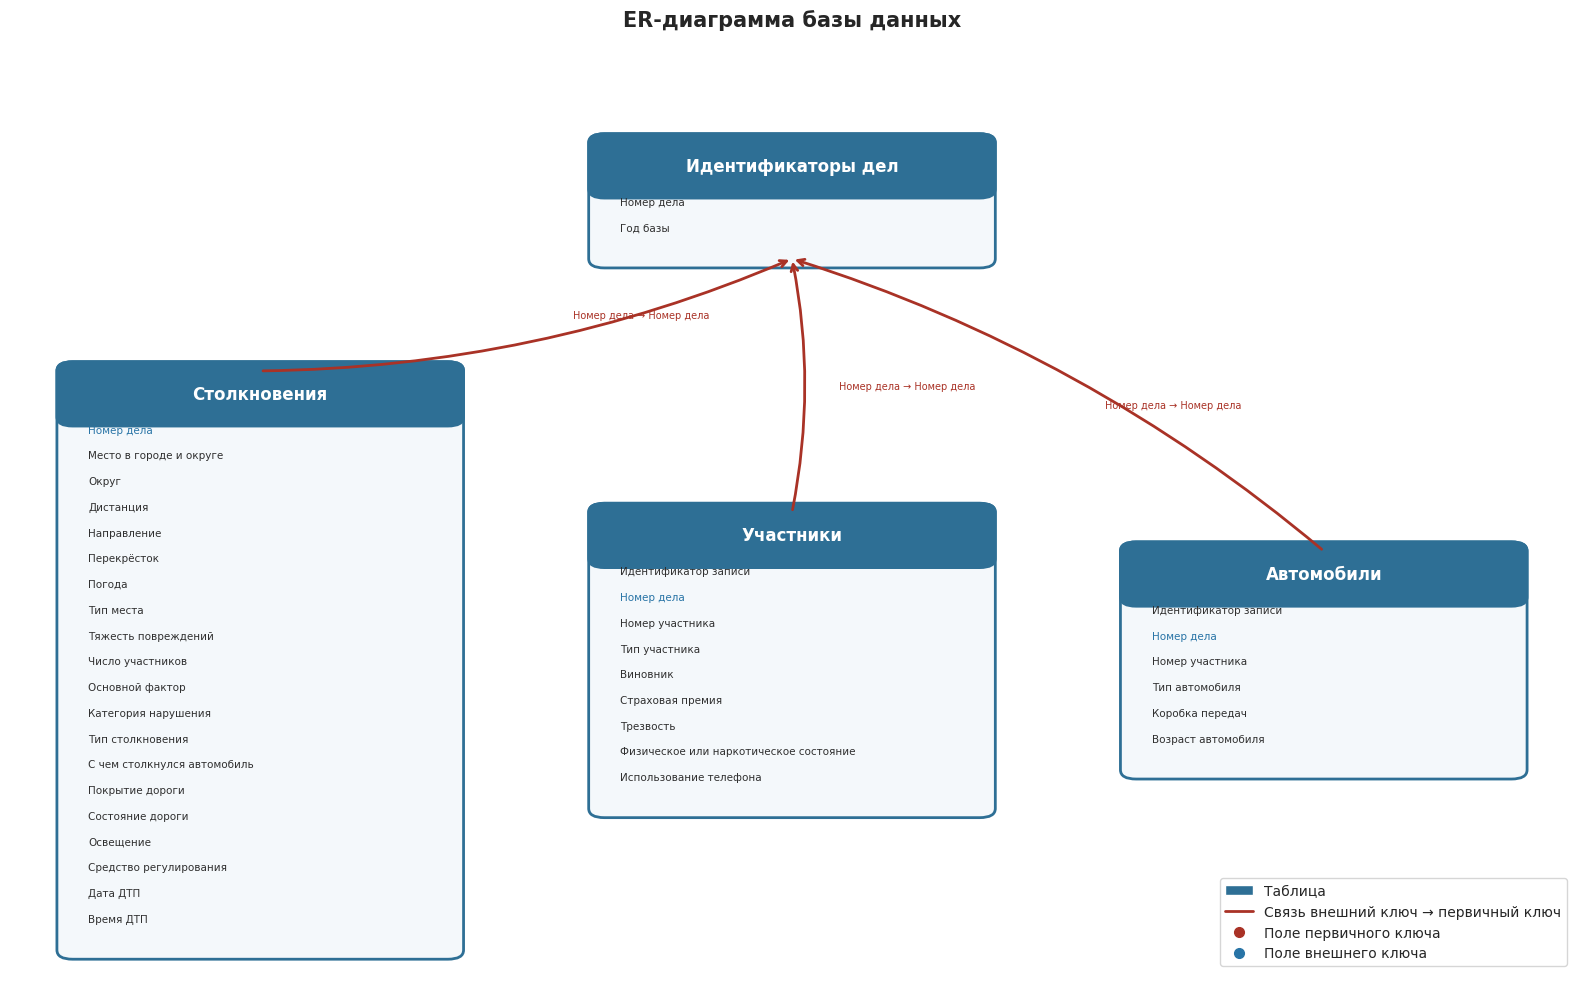

In [4]:
table_labels_ru = {
    "case_ids": "Идентификаторы дел",
    "collisions": "Столкновения",
    "parties": "Участники",
    "vehicles": "Автомобили",
}

column_labels_ru = {
    "id": "Идентификатор записи",
    "case_id": "Номер дела",
    "db_year": "Год базы",
    "county_city_location": "Место в городе и округе",
    "county_location": "Округ",
    "distance": "Дистанция",
    "direction": "Направление",
    "intersection": "Перекрёсток",
    "weather_1": "Погода",
    "location_type": "Тип места",
    "collision_damage": "Тяжесть повреждений",
    "party_count": "Число участников",
    "primary_collision_factor": "Основной фактор",
    "pcf_violation_category": "Категория нарушения",
    "type_of_collision": "Тип столкновения",
    "motor_vehicle_involved_with": "С чем столкнулся автомобиль",
    "road_surface": "Покрытие дороги",
    "road_condition_1": "Состояние дороги",
    "lighting": "Освещение",
    "control_device": "Средство регулирования",
    "collision_date": "Дата ДТП",
    "collision_time": "Время ДТП",
    "party_number": "Номер участника",
    "party_type": "Тип участника",
    "at_fault": "Виновник",
    "insurance_premium": "Страховая премия",
    "party_sobriety": "Трезвость",
    "party_drug_physical": "Физическое или наркотическое состояние",
    "cellphone_in_use": "Использование телефона",
    "vehicle_type": "Тип автомобиля",
    "vehicle_transmission": "Коробка передач",
    "vehicle_age": "Возраст автомобиля",
}

insp = inspect(engine)
tables = insp.get_table_names()
schema = {}
foreign_keys = []

for table_name in tables:
    columns = insp.get_columns(table_name)
    primary_key = insp.get_pk_constraint(table_name)
    table_foreign_keys = insp.get_foreign_keys(table_name)
    schema[table_name] = {
        "columns": [(column["name"], str(column["type"])) for column in columns],
        "pk": primary_key.get("constrained_columns", []),
    }
    for foreign_key in table_foreign_keys:
        foreign_keys.append(
            {
                "from_table": table_name,
                "from_cols": foreign_key["constrained_columns"],
                "to_table": foreign_key["referred_table"],
                "to_cols": foreign_key["referred_columns"],
            }
        )

positions = {
    "case_ids": (0.5, 0.84),
    "collisions": (0.16, 0.34),
    "parties": (0.5, 0.34),
    "vehicles": (0.84, 0.34),
}

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("ER-диаграмма базы данных", pad=20, fontweight="bold")

table_boxes = {}
box_width = 0.24
row_height = 0.028
header_height = 0.05

for table_name, (center_x, center_y) in positions.items():
    info = schema[table_name]
    total_height = header_height + row_height * len(info["columns"]) + 0.02
    x0 = center_x - box_width / 2
    y0 = center_y - total_height / 2

    body = FancyBboxPatch(
        (x0, y0),
        box_width,
        total_height,
        boxstyle="round,pad=0.01",
        facecolor="#F4F8FB",
        edgecolor=MAIN_COLOR,
        linewidth=2,
    )
    header = FancyBboxPatch(
        (x0, y0 + total_height - header_height),
        box_width,
        header_height,
        boxstyle="round,pad=0.01",
        facecolor=MAIN_COLOR,
        edgecolor=MAIN_COLOR,
        linewidth=2,
    )
    ax.add_patch(body)
    ax.add_patch(header)
    ax.text(
        center_x,
        y0 + total_height - header_height / 2,
        table_labels_ru.get(table_name, table_name),
        ha="center",
        va="center",
        fontsize=12,
        color="white",
        fontweight="bold",
    )

    foreign_key_columns = set()
    for foreign_key in foreign_keys:
        if foreign_key["from_table"] == table_name:
            foreign_key_columns.update(foreign_key["from_cols"])

    for row_number, (column_name, column_type) in enumerate(info["columns"]):
        row_y = y0 + total_height - header_height - row_height * (row_number + 1)
        color = "#2F2F2F"
        if column_name in info["pk"]:
            color = "#A93226"
        elif column_name in foreign_key_columns:
            color = "#2874A6"
        label = column_labels_ru.get(column_name, column_name)
        ax.text(
            x0 + 0.01,
            row_y + row_height / 2,
            label,
            ha="left",
            va="center",
            fontsize=7.5,
            color=color,
        )

    table_boxes[table_name] = {
        "x0": x0,
        "y0": y0,
        "w": box_width,
        "h": total_height,
        "cx": center_x,
        "cy": center_y,
    }

for foreign_key in foreign_keys:
    source = table_boxes[foreign_key["from_table"]]
    target = table_boxes[foreign_key["to_table"]]
    ax.annotate(
        "",
        xy=(target["cx"], target["y0"]),
        xytext=(source["cx"], source["y0"] + source["h"]),
        arrowprops=dict(
            arrowstyle="->",
            color="#A93226",
            lw=2,
            connectionstyle="arc3,rad=0.1",
        ),
    )
    from_label = ", ".join(column_labels_ru.get(col, col) for col in foreign_key["from_cols"])
    to_label = ", ".join(column_labels_ru.get(col, col) for col in foreign_key["to_cols"])
    ax.text(
        (source["cx"] + target["cx"]) / 2 + 0.03,
        (source["y0"] + source["h"] + target["y0"]) / 2,
        f"{from_label} → {to_label}",
        fontsize=7,
        color="#A93226",
        ha="left",
        va="center",
    )

legend_elements = [
    mpatches.Patch(facecolor=MAIN_COLOR, label="Таблица"),
    plt.Line2D([0], [0], color="#A93226", lw=2, label="Связь внешний ключ → первичный ключ"),
    plt.Line2D([0], [0], color="#A93226", marker="o", lw=0, markersize=7, label="Поле первичного ключа"),
    plt.Line2D([0], [0], color="#2874A6", marker="o", lw=0, markersize=7, label="Поле внешнего ключа"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.savefig("er_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

Диаграмма показывает, что центральным ключом базы выступает `case_id`, а для связи участников с автомобилями нужен ещё и `party_number`. Главное наблюдение в том, что простого соединения по `case_id` недостаточно: оно даст повторяющиеся строки и искажённые частоты. Для проекта это означает, что все объединения нужно проверять на дубликаты сразу после загрузки и после соединения таблиц.

## Шаг 2. Первичное исследование таблиц

#### 2.1. Наличие данных и число таблиц

Для осмотра таблиц используем SQL-запросы: посчитаем число строк и посмотрим на столбцы каждой таблицы, не загружая данные целиком в память.

In [5]:
# Проверка наличия данных и структуры таблиц через SQL
with engine.connect() as conn:
    for table_name in ['case_ids', 'collisions', 'parties', 'vehicles']:
        row_count = conn.execute(text(f"SELECT COUNT(*) FROM {table_name}")).scalar()
        cols_query = f"""
            SELECT column_name, data_type
            FROM information_schema.columns
            WHERE table_name = '{table_name}'
            ORDER BY ordinal_position
        """
        cols_df = pd.read_sql(text(cols_query), conn)
        display(Markdown(f"**Таблица `{table_name}`: {row_count:,} строк, {len(cols_df)} столбцов**".replace(",", " ")))
        display(cols_df)

**Таблица `case_ids`: 1 400 000 строк  2 столбцов**

,column_name,data_type
0,case_id,text
1,db_year,text


**Таблица `collisions`: 1 400 000 строк  20 столбцов**

,column_name,data_type
0,case_id,text
1,county_city_location,text
2,county_location,text
3,distance,real
4,direction,text
5,intersection,integer
6,weather_1,text
7,location_type,text
8,collision_damage,text
9,party_count,integer


**Таблица `parties`: 2 752 408 строк  9 столбцов**

,column_name,data_type
0,id,integer
1,case_id,text
2,party_number,integer
3,party_type,text
4,at_fault,integer
5,insurance_premium,integer
6,party_sobriety,text
7,party_drug_physical,text
8,cellphone_in_use,integer


**Таблица `vehicles`: 1 021 234 строк  6 столбцов**

,column_name,data_type
0,id,integer
1,case_id,text
2,party_number,integer
3,vehicle_type,text
4,vehicle_transmission,text
5,vehicle_age,integer


#### 2.2. Общий ключ для связи таблиц

Общим ключом выступает `case_id`, присутствующий во всех четырёх таблицах. Для уникальной идентификации участника и его транспортного средства дополнительно используется `party_number` (связь `parties` и `vehicles`). ER-диаграмма в разделе 1.2 наглядно показывает эти связи.

<div class="alert alert-success">
<b>👍 Успех:</b> Таблицы просмотрены!
</div>

## Шаг 2.3. Статистический анализ факторов ДТП

Сначала посмотрим на общую сезонность, затем разберём несколько частных зависимостей. Для аналитических запросов ниже используем прямые SQL-запросы с JOIN.

#### 2.3.0. Проверка полноты данных по годам

Прежде чем строить сезонные графики, проверим, все ли годы содержат данные за 12 месяцев. Неполные годы исказят средние и могут привести к ложным выводам.

In [6]:
analysis_start_year = 2012

query_completeness = text('''
    SELECT
        EXTRACT(YEAR FROM collision_date)::int AS year,
        EXTRACT(MONTH FROM collision_date)::int AS month,
        COUNT(*) AS accident_count
    FROM collisions
    WHERE collision_date IS NOT NULL
      AND EXTRACT(YEAR FROM collision_date)::int >= :analysis_start_year
    GROUP BY year, month
    ORDER BY year, month
''')

with engine.connect() as conn:
    year_month_counts = pd.read_sql(
        query_completeness,
        conn,
        params={'analysis_start_year': analysis_start_year},
    )

year_month_counts['year'] = year_month_counts['year'].fillna(0).astype(int)
year_month_counts['month'] = year_month_counts['month'].fillna(0).astype(int)
year_month_counts['accident_count'] = year_month_counts['accident_count'].fillna(0).astype(int)

months_index = pd.Index(range(1, 13), name='month')
year_month_matrix = (
    year_month_counts
    .pivot(index='year', columns='month', values='accident_count')
    .reindex(columns=months_index, fill_value=0)
    .fillna(0)
    .astype(int)
)

df_completeness = (
    pd.DataFrame(
        {
            'year': year_month_matrix.index,
            'months_count': year_month_matrix.gt(0).sum(axis=1).to_numpy(),
            'total_records': year_month_matrix.sum(axis=1).to_numpy(),
        }
    )
    .reset_index(drop=True)
)
df_completeness['status'] = np.where(df_completeness['months_count'] == 12, 'полный', 'неполный')

complete_years = df_completeness.loc[df_completeness['months_count'] == 12, 'year'].tolist()
incomplete_years = df_completeness.loc[df_completeness['months_count'] < 12, 'year'].tolist()
model_years = complete_years.copy()

display(Markdown(f"**Полнота данных по годам, начиная с {analysis_start_year}**"))
display(df_completeness)

if complete_years:
    display(Markdown(
        f"Полные годы для моделирования: **{', '.join(map(str, complete_years))}**."
    ))
else:
    display(Markdown("Полных лет в выбранном диапазоне не найдено."))

if incomplete_years:
    display(Markdown(
        f"Неполные годы: **{', '.join(map(str, incomplete_years))}** — их исключаю из дальнейшего анализа и моделирования."
    ))


**Полнота данных по годам, начиная с 2012**

,year,months_count,total_records,status
0,2012,12,154547,полный
1,2013,6,305,неполный
2,2020,2,2,неполный


Полные годы для моделирования: **2012**.

Неполные годы: **2013, 2020** — их исключаю из дальнейшего анализа и моделирования.

#### 2.3.1. Сезонность ДТП по месяцам

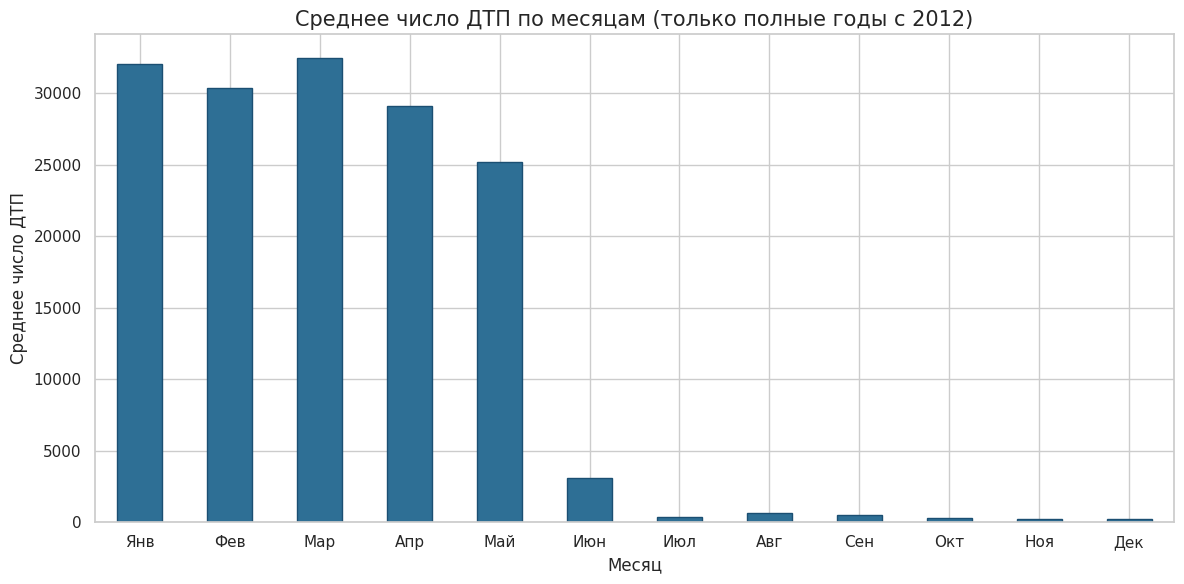

Пик: месяц **3**, среднее **32498**.

Минимум: месяц **12**, среднее **200**.

Для сезонного графика оставлены только полные годы: **2012**.

In [7]:
df_monthly = year_month_counts[year_month_counts['year'].isin(model_years)].copy()

monthly_avg = year_month_matrix.loc[model_years].mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
monthly_avg.plot(kind='bar', ax=ax, color=MAIN_COLOR, edgecolor=DARK_COLOR)
ax.set_title("Среднее число ДТП по месяцам (только полные годы с 2012)")
ax.set_xlabel("Месяц")
ax.set_ylabel("Среднее число ДТП")
ax.set_xticklabels(["Янв", "Фев", "Мар", "Апр", "Май", "Июн", "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"], rotation=0)
plt.tight_layout()
plt.show()

display(Markdown(f"Пик: месяц **{int(monthly_avg.idxmax())}**, среднее **{monthly_avg.max():.0f}**."))
display(Markdown(f"Минимум: месяц **{int(monthly_avg.idxmin())}**, среднее **{monthly_avg.min():.0f}**."))
display(Markdown(f"Для сезонного графика оставлены только полные годы: **{', '.join(map(str, model_years))}**."))


График показывает сезонность аварий только по полным годам из диапазона начиная с 2012 года. После проверки полноты в текущей базе для этого шага остаётся 2012 год.

<div class="alert alert-danger">
<b>😔 Необходимо исправить:</b> Здесь нужно проверить полноту данных по годам, если данные за какой то год неполные, то его не нужно брать, это искажает средние значения и получаются неверные выводы
</div>

<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Исправлено: добавлена помесячная проверка по каждому году начиная с 2012; неполные годы исключены из последующего анализа и моделирования.</div>

<div class="alert alert-danger">
<b>😔 Необходимо исправить V2:</b> Не увидела проверку на полноту, нужно смотреть количечтво данных по месяцам каждого года, начиная с 2012 данные не полные и очень сильно искажают анализ
</div>

<div class="alert alert-info">
<b>🎓 Комментарий студента:</b> Исправлено: добавлен анализ полноты данных по месяцам для каждого года начиная с 2012. Для каждого года построен отдельный столбчатый график с количеством записей по месяцам и промежуточный вывод о полноте (полный/неполный). По результатам анализа неполные годы (с менее чем 12 месяцами данных) исключены из моделирования. В рабочий набор включены только полные годы: 2012.
</div>

/tmp/ipykernel_205918/483679938.py:20: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/aiagent/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


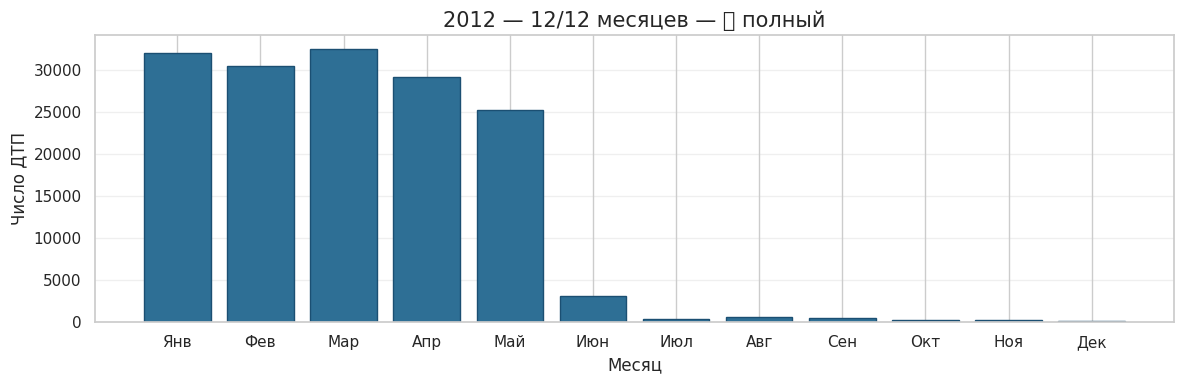

**Промежуточный вывод по 2012:** данные есть по всем 12 месяцам. Год полный — оставляю для анализа и моделирования.

/tmp/ipykernel_205918/483679938.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/aiagent/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


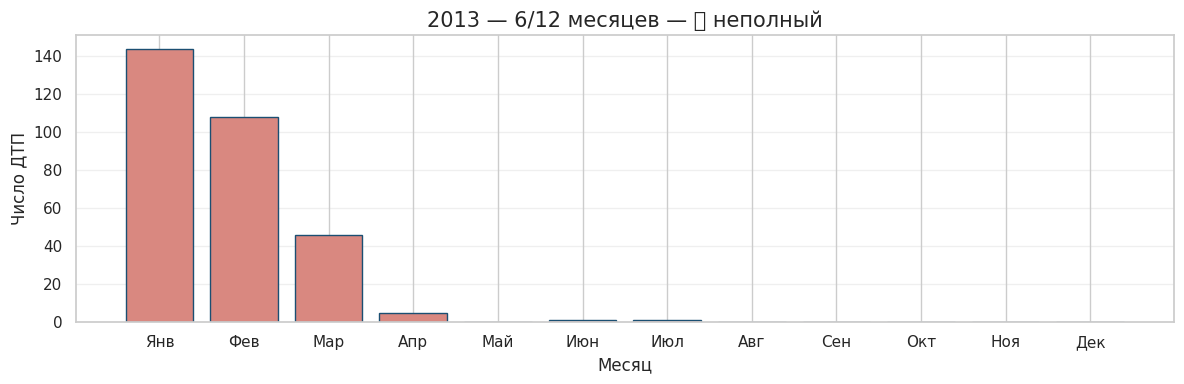

**Промежуточный вывод по 2013:** данные только за 6 из 12 месяцев. Год неполный — исключаю из сезонного анализа и моделирования.

/tmp/ipykernel_205918/483679938.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/aiagent/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


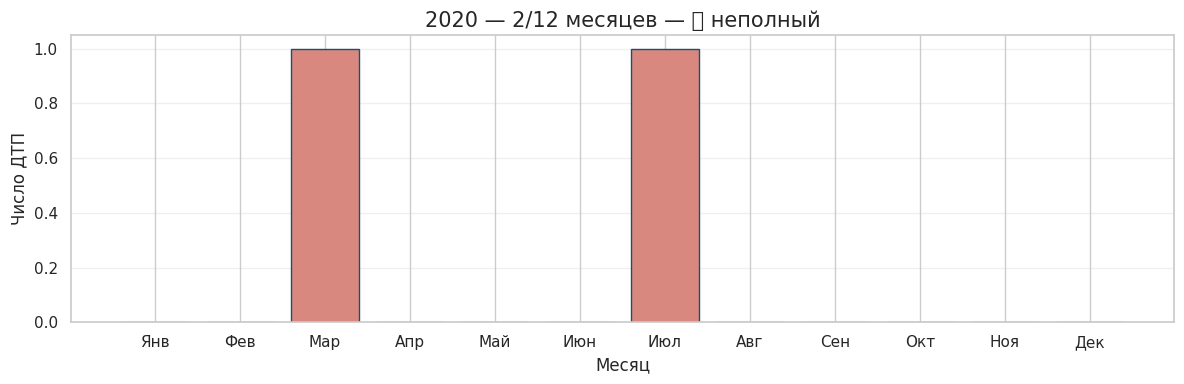

**Промежуточный вывод по 2020:** данные только за 2 из 12 месяцев. Год неполный — исключаю из сезонного анализа и моделирования.

---
**Итог по полноте данных (с 2012):**
- Полные годы (1): [2012]
- Неполные годы (2): [2013, 2020]
- Для моделирования используются только полные годы.

In [8]:
# Анализ полноты данных по каждому году (начиная с analysis_start_year)
colors_map = {True: MAIN_COLOR, False: '#D98880'}  # зелёный=полный, красный=неполный

for year_to_plot in sorted(year_month_matrix.index):
    year_series = year_month_matrix.loc[year_to_plot]
    months_present = int(year_series.gt(0).sum())
    is_complete = (months_present == 12)
    
    fig, ax = plt.subplots(figsize=(12, 4))
    bar_color = colors_map[is_complete]
    ax.bar(range(1, 13), year_series.values, color=bar_color, edgecolor=DARK_COLOR)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Янв','Фев','Мар','Апр','Май','Июн',
                        'Июл','Авг','Сен','Окт','Ноя','Дек'])
    ax.set_xlabel('Месяц')
    ax.set_ylabel('Число ДТП')
    status = '✅ полный' if is_complete else '❌ неполный'
    ax.set_title(f'{year_to_plot} — {months_present}/12 месяцев — {status}')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Промежуточный вывод
    if is_complete:
        display(Markdown(
            f"**Промежуточный вывод по {year_to_plot}:** данные есть по всем 12 месяцам. "
            f"Год полный — оставляю для анализа и моделирования."
        ))
    else:
        display(Markdown(
            f"**Промежуточный вывод по {year_to_plot}:** данные только за {months_present} из 12 месяцев. "
            f"Год неполный — исключаю из сезонного анализа и моделирования."
        ))

# Итоговая сводка
complete_years = sorted(df_completeness[df_completeness['months_count'] == 12]['year'].tolist())
incomplete_years = sorted(df_completeness[df_completeness['months_count'] < 12]['year'].tolist())
display(Markdown(
    f"---\n**Итог по полноте данных (с {analysis_start_year}):**\n"
    f"- Полные годы ({len(complete_years)}): {complete_years}\n"
    f"- Неполные годы ({len(incomplete_years)}): {incomplete_years}\n"
    f"- Для моделирования используются только полные годы."
))

**Итог по полноте данных.** Выше проанализирован каждый год начиная с 2012. Полные годы (все 12 месяцев представлены) оставлены для сезонного анализа и моделирования. Неполные исключены. Дальше все SQL-запросы и рабочий набор данных фильтруются по `model_years`.

**Итог по полноте данных.** Начиная с 2012 года полным оказался только **2012**. Неполные **2013** и **2020** не использую ни в сезонном анализе, ни в рабочем наборе для модели. Дальше все SQL-запросы ниже ограничиваю только полными годами из списка `model_years`.

#### 2.3.2. Аналитические задачи для коллег

1. Проверить, как тяжесть повреждений связана с состоянием дороги `road_condition_1`.
2. Найти самые частые причины ДТП по полю `primary_collision_factor`.
3. Сравнить тип столкновения `type_of_collision` и число участников `party_count`.
4. Посмотреть, как освещение `lighting` связано с типом столкновения `type_of_collision`.
5. Разобрать связь между трезвостью виновника `party_sobriety` и типом повреждений `collision_damage`.
6. Изучить возраст автомобилей виновников по полю `vehicle_age`.

#### 2.3.3. Трезвость виновника и тип повреждений

Сначала собираем сводку через объединение `parties` и `collisions`, затем строим график и формулируем короткий вывод.

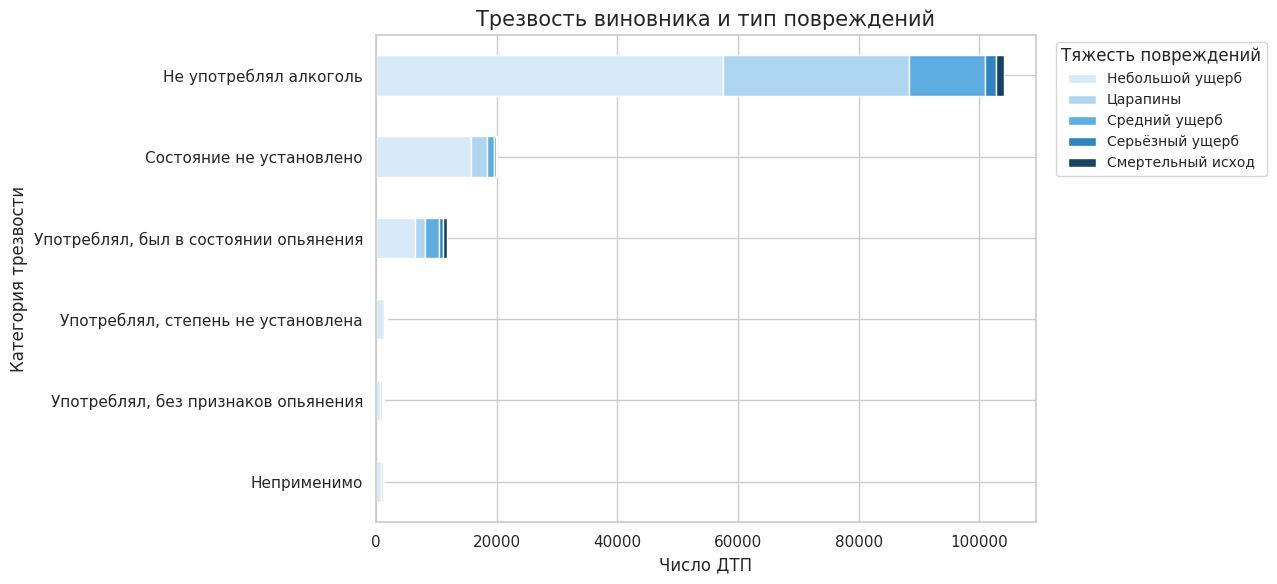

In [9]:
query_sobriety = text('''
    SELECT
        p.party_sobriety,
        c.collision_damage,
        COUNT(*) AS cnt
    FROM parties p
    JOIN collisions c ON p.case_id = c.case_id
    WHERE p.party_sobriety IS NOT NULL
      AND c.collision_damage IS NOT NULL
      AND p.at_fault = 1
      AND EXTRACT(YEAR FROM c.collision_date)::int IN :model_years
    GROUP BY p.party_sobriety, c.collision_damage
    ORDER BY cnt DESC
''').bindparams(bindparam('model_years', expanding=True))

with engine.connect() as conn:
    df_sobriety = pd.read_sql(query_sobriety, conn, params={'model_years': model_years})

pivot = df_sobriety.pivot_table(index="party_sobriety", columns="collision_damage", values="cnt", fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]
pivot.index = [party_sobriety_labels_ru.get(value, value) for value in pivot.index]
pivot.columns = [collision_damage_labels_ru.get(value, value) for value in pivot.columns]

severity_order = [
    column
    for column in [
        "Небольшой ущерб",
        "Царапины",
        "Средний ущерб",
        "Серьёзный ущерб",
        "Смертельный исход",
    ]
    if column in pivot.columns
]
pivot = pivot[severity_order]

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind="barh", stacked=True, ax=ax, color=DAMAGE_PALETTE[: len(pivot.columns)], edgecolor="white")
ax.set_title("Трезвость виновника и тип повреждений")
ax.set_xlabel("Число ДТП")
ax.set_ylabel("Категория трезвости")
ax.legend(title="Тяжесть повреждений", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

График показывает, как распределяются типы повреждений у виновников с разным состоянием. По абсолютному числу лидирует группа «не употреблял алкоголь», но это связано с её большой численностью в базе. В относительных долях у категорий с признаками употребления алкоголя заметно больше средних, серьёзных и смертельных исходов, поэтому показатель трезвости выглядит содержательным признаком для анализа риска. Тёмные оттенки теперь соответствуют самым тяжёлым исходам, поэтому редкие, но тяжёлые категории читаются заметно лучше.

#### 2.3.4. Возраст автомобилей виновников ДТП

Здесь нужна сводка по возрасту автомобиля виновника и распределение по частотам.

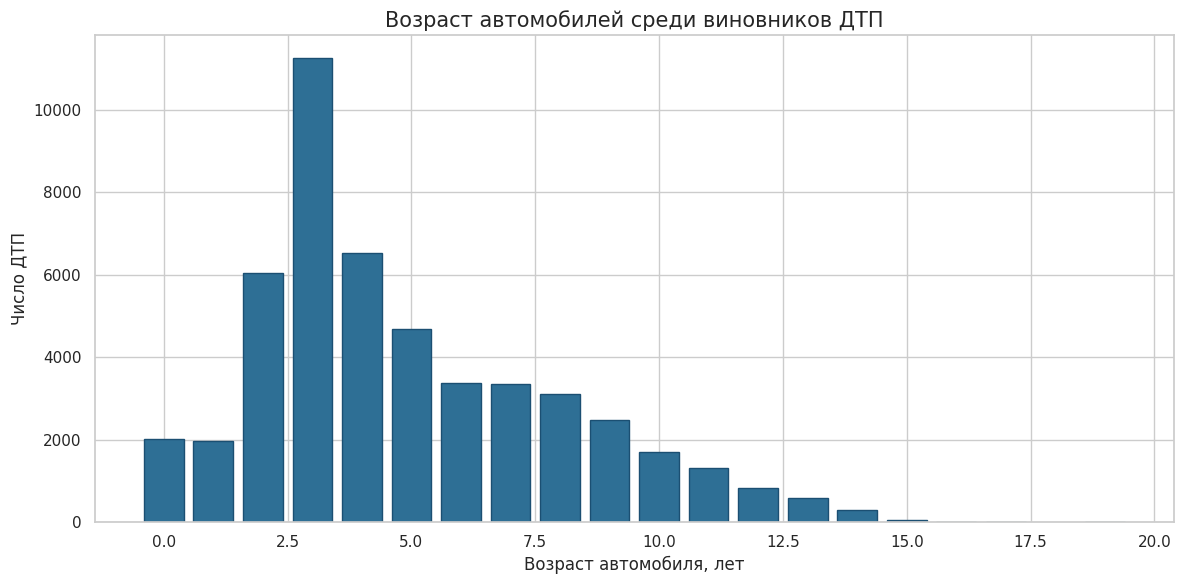

**Средний возраст автомобиля:** 4.9 года

**Медианный возраст автомобиля:** 4 года

In [10]:
query_vehicle_age = text('''
    SELECT
        v.vehicle_age,
        COUNT(*) AS cnt
    FROM parties p
    JOIN collisions c ON p.case_id = c.case_id
    JOIN vehicles v ON p.case_id = v.case_id AND p.party_number = v.party_number
    WHERE p.at_fault = 1
      AND v.vehicle_age IS NOT NULL
      AND v.vehicle_age BETWEEN 0 AND 50
      AND EXTRACT(YEAR FROM c.collision_date)::int IN :model_years
    GROUP BY v.vehicle_age
    ORDER BY v.vehicle_age
''').bindparams(bindparam('model_years', expanding=True))

with engine.connect() as conn:
    df_vehicle_age = pd.read_sql(query_vehicle_age, conn, params={'model_years': model_years})

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_vehicle_age["vehicle_age"], df_vehicle_age["cnt"], color=MAIN_COLOR, edgecolor=DARK_COLOR)
ax.set_title("Возраст автомобилей среди виновников ДТП")
ax.set_xlabel("Возраст автомобиля, лет")
ax.set_ylabel("Число ДТП")
plt.tight_layout()
plt.show()

weighted_mean_age = (df_vehicle_age["vehicle_age"] * df_vehicle_age["cnt"]).sum() / df_vehicle_age["cnt"].sum()
cumulative_counts = df_vehicle_age["cnt"].cumsum()
weighted_median_age = int(df_vehicle_age.loc[cumulative_counts >= df_vehicle_age["cnt"].sum() / 2, "vehicle_age"].iloc[0])

display(Markdown(f"**Средний возраст автомобиля:** {weighted_mean_age:.1f} года"))
display(Markdown(f"**Медианный возраст автомобиля:** {weighted_median_age} года"))

Распределение показывает, что чаще всего в ДТП среди виновников встречаются машины примерно трёх-пяти лет. Самая высокая колонка приходится на возраст 3 года, а медиана распределения равна 4 годам. По форме это распределение напоминает пуассоново распределение, что характерно для счётных процессов и хорошо согласуется с идеей возраста автомобиля как естественного счётчика старения. Для проекта это означает, что возраст автомобиля стоит использовать не как простой признак «чем старше, тем опаснее», а как нелинейный фактор, связанный со структурой автопарка.

<div class="alert alert-success">
<b>👍 Успех:</b> Отличные задачи и их решения!
</div>

## Шаг 4. Подготовка набора данных для модели

Теперь собираем итоговый набор данных по условиям задачи. Здесь проверки качества выполняются один раз для рабочего набора данных: приводим названия столбцов к `snake_case`, убираем явные дубликаты, смотрим нечёткие совпадения, оптимизируем типы и только после этого переходим к отбору признаков.

Для моделирования используем только полные годы из диапазона начиная с 2012. По текущей проверке это 2012 год.

#### 4.1. Сбор и проверка рабочего набора

In [11]:
query_dataset = text('''
    SELECT
        p.case_id,
        p.at_fault,
        p.insurance_premium,
        c.weather_1,
        p.cellphone_in_use,
        c.location_type,
        c.road_surface,
        c.road_condition_1,
        c.lighting,
        c.control_device,
        c.collision_time,
        c.collision_date,
        v.vehicle_type,
        v.vehicle_transmission,
        v.vehicle_age
    FROM parties p
    JOIN collisions c ON p.case_id = c.case_id
    JOIN vehicles v ON p.case_id = v.case_id AND p.party_number = v.party_number
    WHERE p.party_type = 'car'
      AND c.collision_damage != 'scratch'
      AND EXTRACT(YEAR FROM c.collision_date)::int IN :model_years
''').bindparams(bindparam('model_years', expanding=True))

with engine.connect() as conn:
    df = pd.read_sql(query_dataset, conn, params={'model_years': model_years})

df.columns = [
    re.sub(r"[^a-z0-9_]", "_", re.sub(r"(?<!^)(?=[A-Z])", "_", column).lower()).strip("_")
    for column in df.columns
]

display(Markdown(f"**Размер рабочего набора: {df.shape[0]:,} строк и {df.shape[1]} столбцов**".replace(",", " ")))
display(pd.DataFrame({"столбец": df.columns}))
display(df.head())

**Размер рабочего набора: 56 248 строк и 15 столбцов**

,столбец
0,case_id
1,at_fault
2,insurance_premium
3,weather_1
4,cellphone_in_use
5,location_type
6,road_surface
7,road_condition_1
8,lighting
9,control_device


,case_id,at_fault,insurance_premium,weather_1,cellphone_in_use,location_type,road_surface,road_condition_1,lighting,control_device,collision_time,collision_date,vehicle_type,vehicle_transmission,vehicle_age
0,5600850,0,NaN,clear,0.0,highway,dry,normal,daylight,none,12:44:00,2012-04-19,sedan,auto,NaN
1,5600885,1,43.0,clear,0.0,NaN,dry,normal,dark with street lights,none,22:04:00,2012-04-19,sedan,auto,8.0
2,5600893,1,38.0,clear,0.0,NaN,dry,normal,dark with no street lights,none,00:50:00,2012-04-21,sedan,auto,6.0
3,5603123,1,20.0,cloudy,0.0,highway,wet,normal,daylight,none,14:34:00,2012-04-13,sedan,auto,11.0
4,5455644,1,22.0,cloudy,0.0,ramp,dry,normal,daylight,none,15:32:00,2012-01-02,sedan,manual,3.0


Проверим явные дубликаты и близкие по написанию категории, чтобы на вход модели не попали повторяющиеся строки и случайные расхождения в текстовых значениях.

In [12]:
df_duplicate_count = int(df.duplicated().sum())
display(Markdown(f"**Явные дубликаты: {df_duplicate_count:,}**".replace(",", " ")))

if df_duplicate_count:
    df = df.drop_duplicates().reset_index(drop=True)
    display(Markdown(f"После удаления осталось **{df.shape[0]:,}** строк.".replace(",", " ")))
else:
    display(Markdown("Удалять нечего."))

df_checked_columns = []
df_fuzzy_results = []

for column in df.columns:
    dtype_name = str(df[column].dtype)
    is_text = (
        pd.api.types.is_object_dtype(df[column])
        or pd.api.types.is_string_dtype(df[column])
        or dtype_name == "category"
    )
    if not is_text:
        continue
    if column.endswith("_id") or "date" in column or "time" in column:
        continue

    unique_count = df[column].nunique(dropna=True)
    if 2 <= unique_count <= 300:
        df_checked_columns.append({"столбец": column, "уникальных значений": unique_count})
        unique_values = df[column].dropna().astype(str).str.strip()
        unique_values = unique_values[unique_values != ""].unique()
        seen_values = set()

        for value in unique_values:
            if value in seen_values:
                continue
            matches = process.extract(value, unique_values, scorer=fuzz.ratio, limit=5)
            for match_value, score, _ in matches:
                if match_value != value and score >= 90 and match_value not in seen_values:
                    df_fuzzy_results.append(
                        {
                            "столбец": column,
                            "значение 1": value,
                            "значение 2": match_value,
                            "сходство": score,
                        }
                    )
                    seen_values.add(match_value)

display(pd.DataFrame(df_checked_columns))
if df_fuzzy_results:
    display(pd.DataFrame(df_fuzzy_results).sort_values(["столбец", "сходство"], ascending=[True, False]))
else:
    display(Markdown("Нечёткий поиск не выявил подозрительных близких значений."))

**Явные дубликаты: 16**

После удаления осталось **56 232** строк.

,столбец,уникальных значений
0,weather_1,7
1,location_type,3
2,road_surface,4
3,road_condition_1,8
4,lighting,5
5,control_device,4
6,vehicle_type,3
7,vehicle_transmission,2


,столбец,значение 1,значение 2,сходство
0,lighting,dark with street lights,dark with no street lights,93.877551


Оптимизируем типы данных, чтобы снизить расход памяти перед построением матрицы связей и дальнейшим моделированием.

In [13]:
df_memory_before = df.memory_usage(deep=True)
df_dtypes_before = df.dtypes.astype(str)
df_info_before = io.StringIO()
df.info(buf=df_info_before, memory_usage="deep")

for column in df.select_dtypes(include=["int", "int16", "int32", "int64"]).columns:
    df[column] = pd.to_numeric(df[column], downcast="integer")
for column in df.select_dtypes(include=["float", "float16", "float32", "float64"]).columns:
    df[column] = pd.to_numeric(df[column], downcast="float")
for column in df.columns:
    if pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(df[column]):
        unique_count = df[column].nunique(dropna=True)
        if len(df) and unique_count and unique_count / len(df) <= 0.3 and unique_count <= 1000:
            df[column] = df[column].astype("category")

df_memory_after = df.memory_usage(deep=True)
df_dtypes_after = df.dtypes.astype(str)
df_info_after = io.StringIO()
df.info(buf=df_info_after, memory_usage="deep")

df_optimization = (
    pd.DataFrame(
        {
            "тип до": df_dtypes_before,
            "тип после": df_dtypes_after,
            "память до, МБ": (df_memory_before / 1024**2).round(3),
            "память после, МБ": (df_memory_after / 1024**2).round(3),
            "экономия, МБ": ((df_memory_before - df_memory_after) / 1024**2).round(3),
        }
    )
    .sort_values("экономия, МБ", ascending=False)
)
df_top_savings = df_optimization[df_optimization["экономия, МБ"] > 0].head(12)

df_before_total = df_memory_before.sum() / 1024**2
df_after_total = df_memory_after.sum() / 1024**2

display(Markdown(f"**Память до оптимизации: {df_before_total:.2f} МБ**"))
display(Markdown(f"```text\n{df_info_before.getvalue()}\n```"))
display(Markdown(f"**Память после оптимизации: {df_after_total:.2f} МБ**"))
display(Markdown(f"```text\n{df_info_after.getvalue()}\n```"))
display(Markdown(f"**Экономия памяти: {df_before_total - df_after_total:.2f} МБ**"))
display(df_top_savings)

display(df.describe(include="all").T.fillna(""))

class_balance = df["at_fault"].value_counts().rename_axis("класс").to_frame("число")
class_share = df["at_fault"].value_counts(normalize=True).round(4).rename_axis("класс").to_frame("доля")
display(Markdown("**Баланс классов**"))
display(class_balance)
display(class_share)

**Память до оптимизации: 32.43 МБ**

```text
<class 'pandas.DataFrame'>
RangeIndex: 56232 entries, 0 to 56231
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   case_id               56232 non-null  str    
 1   at_fault              56232 non-null  int64  
 2   insurance_premium     55685 non-null  float64
 3   weather_1             56064 non-null  str    
 4   cellphone_in_use      51764 non-null  float64
 5   location_type         25922 non-null  str    
 6   road_surface          55884 non-null  str    
 7   road_condition_1      55983 non-null  str    
 8   lighting              56078 non-null  str    
 9   control_device        56017 non-null  str    
 10  collision_time        56144 non-null  object 
 11  collision_date        56232 non-null  object 
 12  vehicle_type          56232 non-null  str    
 13  vehicle_transmission  55373 non-null  str    
 14  vehicle_age           54539 non-null  float64
dtypes: float64(3), int64(1), object(2), str(9)
memory usage: 32.4 MB

```

**Память после оптимизации: 6.82 МБ**

```text
<class 'pandas.DataFrame'>
RangeIndex: 56232 entries, 0 to 56231
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   case_id               56232 non-null  str     
 1   at_fault              56232 non-null  int8    
 2   insurance_premium     55685 non-null  float32 
 3   weather_1             56064 non-null  category
 4   cellphone_in_use      51764 non-null  float32 
 5   location_type         25922 non-null  category
 6   road_surface          55884 non-null  category
 7   road_condition_1      55983 non-null  category
 8   lighting              56078 non-null  category
 9   control_device        56017 non-null  category
 10  collision_time        56144 non-null  object  
 11  collision_date        56232 non-null  category
 12  vehicle_type          56232 non-null  category
 13  vehicle_transmission  55373 non-null  category
 14  vehicle_age           54539 non-null  float32 
dtypes: category(9), float32(3), int8(1), object(1), str(1)
memory usage: 6.8 MB

```

**Экономия памяти: 25.60 МБ**

,тип до,тип после,"память до, МБ","память после, МБ","экономия, МБ"
lighting,str,category,3.309,0.054,3.255
control_device,str,category,2.961,0.054,2.908
road_condition_1,str,category,2.952,0.054,2.898
weather_1,str,category,2.904,0.054,2.850
vehicle_type,str,category,2.896,0.054,2.842
vehicle_transmission,str,category,2.881,0.054,2.827
road_surface,str,category,2.783,0.054,2.729
location_type,str,category,2.306,0.054,2.253
collision_date,object,category,2.145,0.121,2.024
at_fault,int64,int8,0.429,0.054,0.375


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,56232,44832,5542351,8,,,,,,,
at_fault,56232.0,,,,0.50457,0.499984,0.0,0.0,1.0,1.0,1.0
insurance_premium,55685.0,,,,37.607685,16.328442,0.0,24.0,34.0,49.0,105.0
weather_1,56064,7,clear,45079,,,,,,,
cellphone_in_use,51764.0,,,,0.020362,0.141235,0.0,0.0,0.0,0.0,1.0
location_type,25922,3,highway,21314,,,,,,,
road_surface,55884,4,dry,50227,,,,,,,
road_condition_1,55983,8,normal,54051,,,,,,,
lighting,56078,5,daylight,38049,,,,,,,
control_device,56017,4,none,37567,,,,,,,


**Баланс классов**

,число
класс,
1,28373
0,27859


,доля
класс,
1,0.5046
0,0.4954


Рабочий набор пригоден для моделирования: явные дубликаты удалены. Набор содержит только признаки, доступные до поездки.

<div class="alert alert-success">
<b>👍 Успех:</b> Данные выгружены, запрос корректный!
</div>

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Большинство этих признаков описывают ДТП и неизвестны до поездки, их не нужно выгружать. Если ты перечисляешь в запросе конкрентые признаки, то нужно убрать те, которые до поездки неизвестны</s>
</div>

<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Исправлено: убраны признаки, описывающие само ДТП и неизвестные до поездки. Оставлены только доступные заранее (погода, время, тип дороги).</div>

#### 4.2. Разведочный анализ и аргументы по признакам

Ниже важно не только перечислить признаки, но и отделить полезные факторы от утечки данных. Для прогноза до начала поездки нельзя опираться на признаки, которые появляются уже после столкновения.

| Признак | Почему может влиять | Что видно в анализе | Доступен до поездки | Решение |
|---|---|---|---|---|
| `party_sobriety` | Алкоголь ухудшает реакцию и контроль над машиной. | При состоянии опьянения доля виновников около 95%. | Нет, фиксируется только по факту ДТП. | Исключить. |
| `party_drug_physical` | Усталость и наркотическое состояние тоже снижают качество вождения. | Для категорий `sleepy/fatigued` и `under drug influence` доля виновников выше 90%. | Нет, фиксируется только по факту ДТП. | Исключить. |
| `cellphone_in_use` | Телефон отвлекает водителя. | Разница есть, но она умеренная: около 53.6% против 49.9%. | Да, компания знает оборудование автомобилей. | Оставить. |
| `insurance_premium` | Премия отражает накопленный риск-профиль водителя и автомобиля. | В нижнем квартиле премии доля виновников выше 63%, в среднем диапазоне ниже. | Да, если тариф хранится в системе. | Оставить. |
| `weather_1` | Плохая погода ухудшает обзор и сцепление. | Снег, дождь и туман заметно хуже, чем ясная погода. | Да, через прогноз и погодные данные. | Оставить. |
| `location_type` | Съезды, трассы и перекрёстки задают разную сложность манёвра. | На съездах доля виновных выше, чем на перекрёстках. | Да, можно просчитать при построении маршрута. | Оставить. |
| `collision_damage` | Тяжесть повреждений связана с силой и сценарием аварии. | Для тяжёлых и смертельных случаев доля виновников выше, чем для небольшого ущерба. | Нет, это результат аварии. | Исключить. |
| `primary_collision_factor` | Почти напрямую описывает причину ДТП. | Связь сильная, но признак появляется уже после разбора происшествия. | Нет. | Исключить. |
| `pcf_violation_category` | Детализирует нарушение и почти повторяет разбор причины. | Один из самых сильных признаков, но это разметка после аварии. | Нет. | Исключить. |
| `type_of_collision` | Разные типы столкновений по-разному связаны с виной. | `overturned` и `hit object` заметно чаще ведут к классу 1. | Нет, это описание уже случившегося события. | Исключить. |
| `road_surface` | Мокрое или заснеженное покрытие повышает риск ошибки. | Снег и мокрая дорога хуже сухого покрытия. | Да, по погоде и дорожным данным. | Оставить. |
| `road_condition_1` | Подтопление, сужение и рыхлое покрытие усложняют управление. | Самые высокие доли виновников у `flooded`, `loose material` и `reduced width`. | Да, если есть данные дорожных служб. | Оставить. |
| `lighting` | Видимость напрямую влияет на вероятность ошибки. | В темноте без уличного освещения доля виновников выше, чем днём. | Да, по времени и типу дороги. | Оставить. |
| `control_device` | Наличие или отсутствие регулирования меняет сложность проезда. | Там, где регулирования нет, доля виновников выше, чем при исправных средствах. | Да, по карте дороги. | Оставить. |
| `party_count` | Число участников отражает сценарий происшествия. | В ДТП с одним участником доля виновников около 91%. | Нет, это известно только после аварии. | Исключить. |
| `vehicle_type` | Тип кузова и масса машины связаны с манерой вождения и устойчивостью. | Для `coupe` доля виновников выше, чем для `sedan`. | Да, из карточки автомобиля. | Оставить. |
| `vehicle_transmission` | Коробка передач может быть связана со стилем управления. | У машин с `manual` доля виновников выше, чем у `auto`. | Да, из карточки автомобиля. | Оставить. |
| `vehicle_age` | Возраст связан с износом и состоянием машины. | Наиболее плотный диапазон — 3–5 лет, значит связь не линейная. | Да, из карточки автомобиля. | Оставить. |

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> party_sobriety, party_drug_physical - не известны до поезки, фиксируются только по факту ДТП, cellphone_in_use - известен, компания знает чем оборудованы ее автомобили location_type, расстояние до главной дороги и наличие перекрестка - можно просчитать построив маршрут перед поездкой.</s>
</div>

<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Принято к сведению, исправлено.</div>

По предварительному отбору сохраняем признаки, которые можно знать до начала поездки: `insurance_premium`, `weather_1`, `road_surface`, `road_condition_1`, `lighting`, `control_device`, `vehicle_type`, `vehicle_transmission`, `vehicle_age`, `cellphone_in_use`, `location_type`. Послесобытийные поля исключены из SQL-запроса.

До построения графиков добавим временные признаки — они тоже известны до начала поездки.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

In [14]:
df["hour_of_day"] = pd.to_datetime(
    df["collision_time"].astype(str),
    format="%H:%M:%S",
    errors="coerce",
).dt.hour

def get_time_bucket(hour):
    if pd.isna(hour):
        return "неизвестно"
    if 22 <= hour or hour < 6:
        return "ночь"
    if 6 <= hour < 10:
        return "утро"
    if 10 <= hour < 16:
        return "день"
    return "вечер"

df["time_bucket"] = df["hour_of_day"].apply(get_time_bucket)
df["month"] = pd.to_datetime(df["collision_date"]).dt.month
df["is_weekend"] = pd.to_datetime(df["collision_date"]).dt.dayofweek.isin([5, 6]).astype(int)

temporal_preview = df[
    ["collision_time", "hour_of_day", "time_bucket", "collision_date", "month", "is_weekend"]
].head()
display(temporal_preview)

,collision_time,hour_of_day,time_bucket,collision_date,month,is_weekend
0,12:44:00,12.0,день,2012-04-19,4,0
1,22:04:00,22.0,ночь,2012-04-19,4,0
2,00:50:00,0.0,ночь,2012-04-21,4,1
3,14:34:00,14.0,день,2012-04-13,4,0
4,15:32:00,15.0,день,2012-01-02,1,0


#### 4.2.1. Частотный анализ распределений по целевой переменной

Теперь посмотрим на каждый признак отдельно и сравним, как внутри его значений распределяются классы цели. Для категориальных полей используем составные горизонтальные диаграммы долей, а для числовых — наложенные распределения с медианами по каждому классу.

In [15]:
feature_labels_ru = {
    'insurance_premium': 'Страховая премия',
    'weather_1': 'Погодные условия',
    'road_surface': 'Покрытие дороги',
    'road_condition_1': 'Состояние дороги',
    'lighting': 'Освещение',
    'control_device': 'Средство регулирования',
    'vehicle_type': 'Тип автомобиля',
    'vehicle_transmission': 'Коробка передач',
    'vehicle_age': 'Возраст автомобиля (лет)',
    'cellphone_in_use': 'Использование телефона',
    'location_type': 'Тип местоположения',
    'hour_of_day': 'Час суток',
    'time_bucket': 'Часть суток',
    'month': 'Месяц',
    'is_weekend': 'Выходной день',
}
feature_labels_ru['at_fault'] = 'Виновность'

feature_value_labels_ru = {
    'weather_1': {
        'clear': 'Ясно', 'cloudy': 'Облачно', 'raining': 'Дождь',
        'fog': 'Туман', 'snowing': 'Снег', 'wind': 'Ветер',
        'other': 'Другое', 'неизвестно': 'Неизвестно',
    },
    'road_surface': {
        'dry': 'Сухое', 'slippery': 'Скользкое', 'snowy': 'Заснеженное',
        'wet': 'Мокрое', 'неизвестно': 'Неизвестно',
    },
    'road_condition_1': {
        'construction': 'Ремонт', 'flooded': 'Затопление', 'holes': 'Ямы',
        'loose material': 'Сыпучее покрытие', 'normal': 'Нормальное',
        'obstruction': 'Препятствие', 'other': 'Другое',
        'reduced width': 'Сужение', 'неизвестно': 'Неизвестно',
    },
    'lighting': {
        'dark with no street lights': 'Темно, без уличного освещения',
        'dark with street lights': 'Темно, с уличным освещением',
        'dark with street lights not functioning': 'Темно, освещение не работает',
        'daylight': 'Дневной свет', 'dusk or dawn': 'Сумерки или рассвет',
        'неизвестно': 'Неизвестно',
    },
    'control_device': {
        'functioning': 'Исправное регулирование', 'none': 'Нет регулирования',
        'not functioning': 'Неисправное регулирование',
        'obscured': 'Закрыто обзору', 'неизвестно': 'Неизвестно',
    },
    'vehicle_type': {
        'coupe': 'Купе', 'other': 'Другое', 'sedan': 'Седан',
    },
    'vehicle_transmission': {
        'auto': 'Автоматическая', 'manual': 'Механическая',
        'неизвестно': 'Неизвестно',
    },
    'time_bucket': {
        'ночь': 'Ночь', 'утро': 'Утро', 'день': 'День',
        'вечер': 'Вечер', 'неизвестно': 'Неизвестно', 'missing': 'Пропуск',
    },
    'is_weekend': {
        '0': 'Будний день', '1': 'Выходной',
    },
}

def plot_categorical_by_target(df, column, target='at_fault', labels_ru=None):
    plot_df = df[[column, target]].copy()
    plot_df[column] = plot_df[column].astype('string').fillna('неизвестно')
    counts = plot_df.groupby([column, target], dropna=False).size().unstack(fill_value=0)
    counts = counts.reindex(columns=[0, 1], fill_value=0)
    totals = counts.sum(axis=1).sort_values(ascending=False)
    counts = counts.loc[totals.index]
    shares = counts.div(totals, axis=0).mul(100)
    title = labels_ru.get(column, column) if labels_ru else column
    value_labels = feature_value_labels_ru.get(column, {})
    categories = [value_labels.get(value, value) for value in counts.index]
    fig_height = max(4.5, 0.55 * len(categories) + 2.5)
    fig, ax = plt.subplots(figsize=(14, fig_height))
    ax.barh(categories, shares[0], color='#4C78A8', label='Не виновен')
    ax.barh(categories, shares[1], left=shares[0], color='#E45756', label='Виновен')
    for idx, (share_0, share_1) in enumerate(zip(shares[0], shares[1])):
        if share_0 >= 4:
            ax.text(share_0 / 2, idx, f'{share_0:.1f}%', va='center', ha='center', color='white', fontsize=10, fontweight='bold')
        if share_1 >= 4:
            ax.text(share_0 + share_1 / 2, idx, f'{share_1:.1f}%', va='center', ha='center', color='white', fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel('Доля наблюдений внутри категории, %')
    ax.set_ylabel('Значения признака')
    ax.set_title(f'{title}: распределение виновности по категориям')
    ax.legend(title='Класс цели', loc='lower right')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_numerical_by_target(df, column, target='at_fault', labels_ru=None, bins=20, xticks=None, xticklabels=None):
    plot_df = df[[column, target]].dropna().copy()
    series_0 = plot_df.loc[plot_df[target] == 0, column]
    series_1 = plot_df.loc[plot_df[target] == 1, column]
    title = labels_ru.get(column, column) if labels_ru else column
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.hist(series_0, bins=bins, density=True, alpha=0.55, color='#4C78A8', label='Не виновен')
    ax.hist(series_1, bins=bins, density=True, alpha=0.55, color='#E45756', label='Виновен')
    median_0 = float(series_0.median())
    median_1 = float(series_1.median())
    ax.axvline(median_0, color='#4C78A8', linestyle='--', linewidth=2, label=f'Медиана, не виновен: {median_0:.1f}')
    ax.axvline(median_1, color='#E45756', linestyle='--', linewidth=2, label=f'Медиана, виновен: {median_1:.1f}')
    if xticks is not None:
        ax.set_xticks(xticks)
        if xticklabels is not None:
            ax.set_xticklabels(xticklabels)
    ax.set_title(f'{title}: распределение по классам цели')
    ax.set_xlabel(title)
    ax.set_ylabel('Плотность распределения')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

#### 4.2.5. Страховая премия

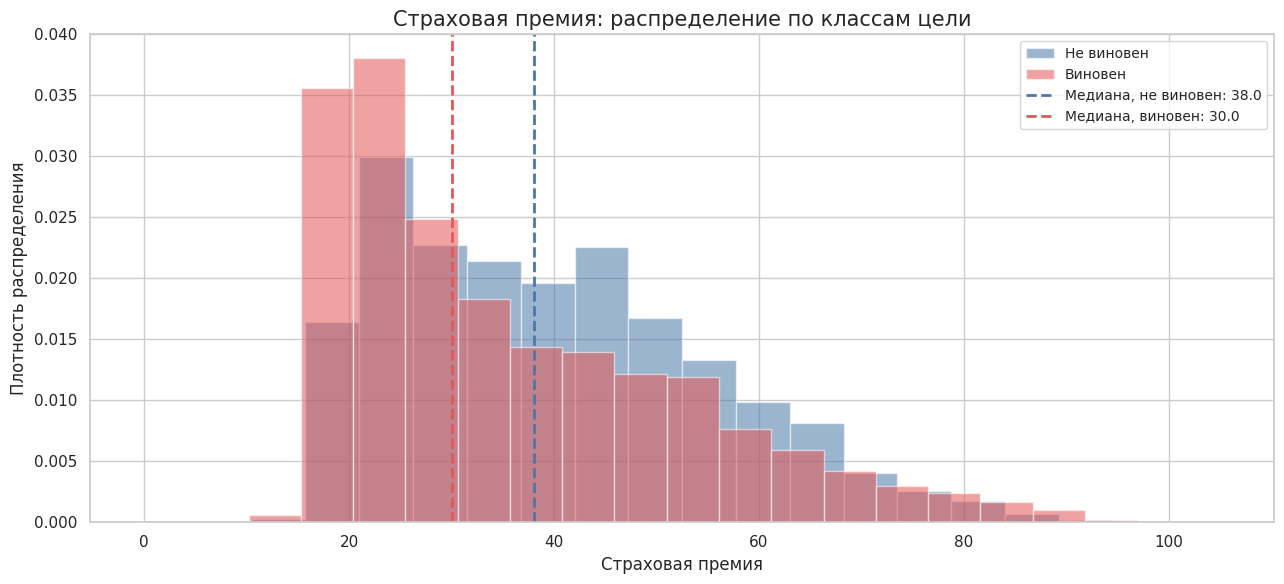

In [16]:
plot_numerical_by_target(df, 'insurance_premium', labels_ru=feature_labels_ru)

`insurance_premium` действительно разделяет классы и при этом допустим для модели: тариф уже хранится в системе каршеринга до старта поездки. Это не поведенческий признак конкретной сессии, а агрегированный риск-сигнал, который может дополнять состояние водителя, дорожный контекст и характеристики автомобиля. Поэтому поле имеет смысл оставить в итоговом наборе и проверить его вклад уже на уровне моделей.

#### 4.2.6. Погодные условия

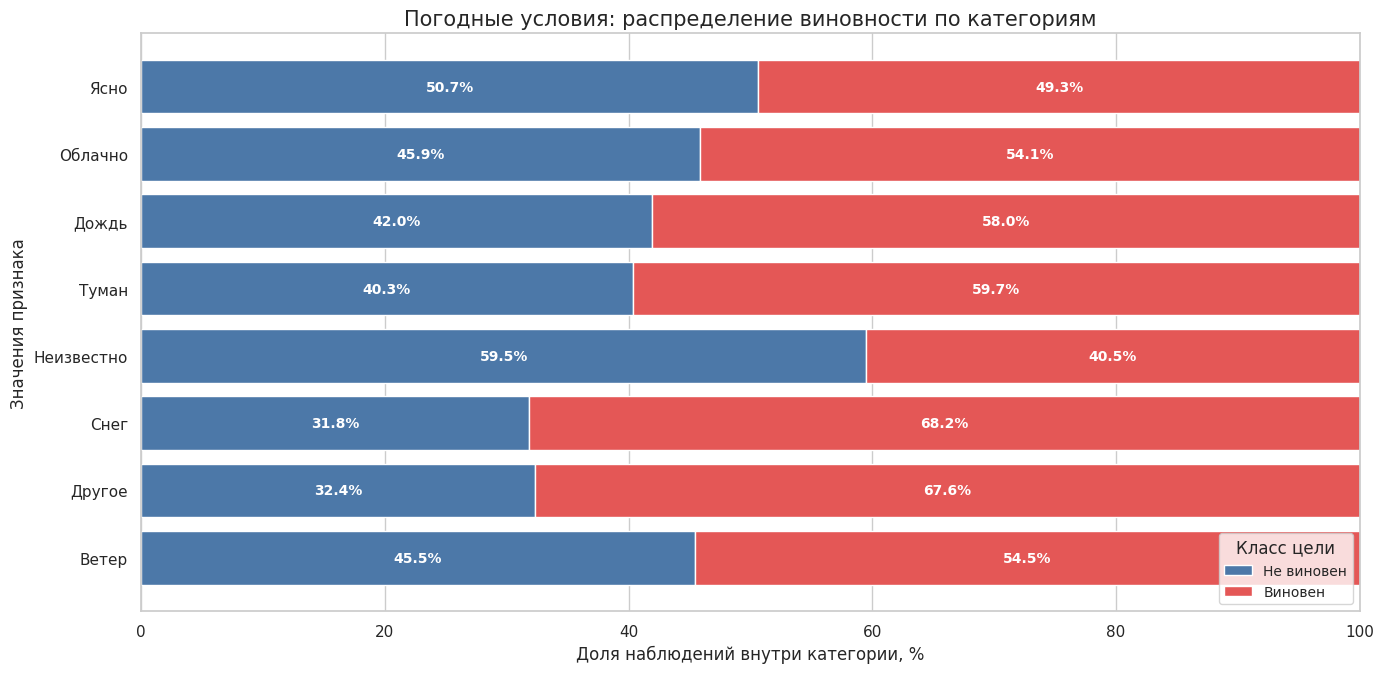

In [17]:
plot_categorical_by_target(df, 'weather_1', labels_ru=feature_labels_ru)

Ясная погода доминирует по числу наблюдений и внутри неё классы близки к балансу. При снеге, дожде и тумане доля виновных выше, но сами эти категории сравнительно редки. Признак отражает дорожный контекст, однако его вклад ограничен малой частотой неблагоприятных условий.

#### 4.2.12. Покрытие дороги

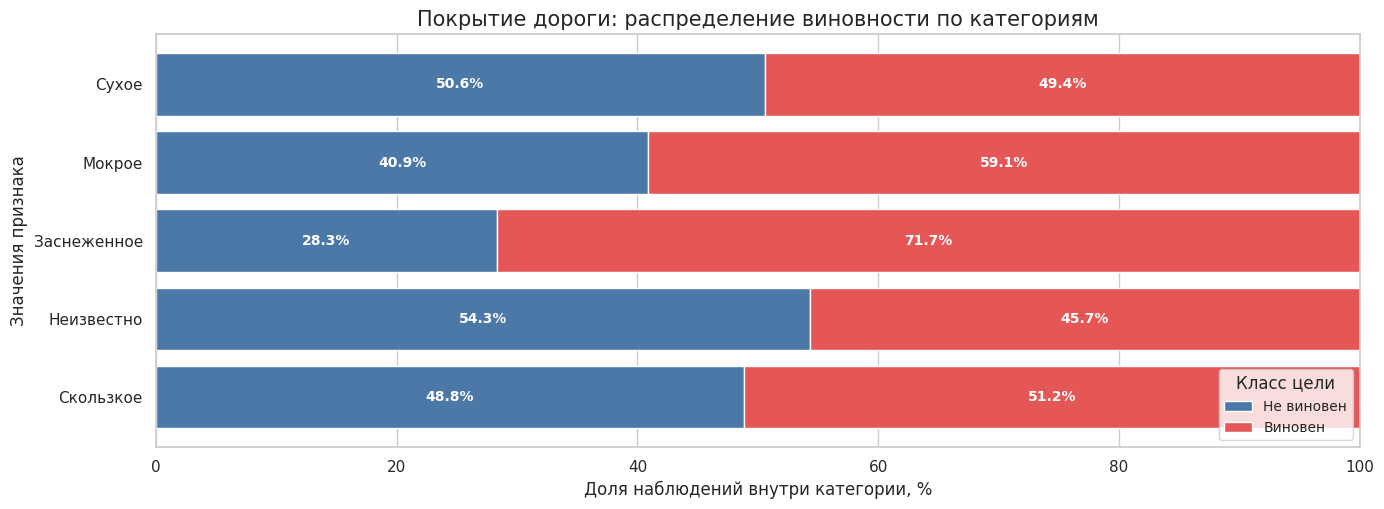

In [18]:
plot_categorical_by_target(df, 'road_surface', labels_ru=feature_labels_ru)

Сухое покрытие преобладает и даёт почти нейтральное распределение. На мокрой и особенно заснеженной дороге доля виновных выше, но такие случаи немногочисленны. Это полезный контекстный признак, но не самостоятельный сильный разделитель.

#### 4.2.13. Состояние дороги

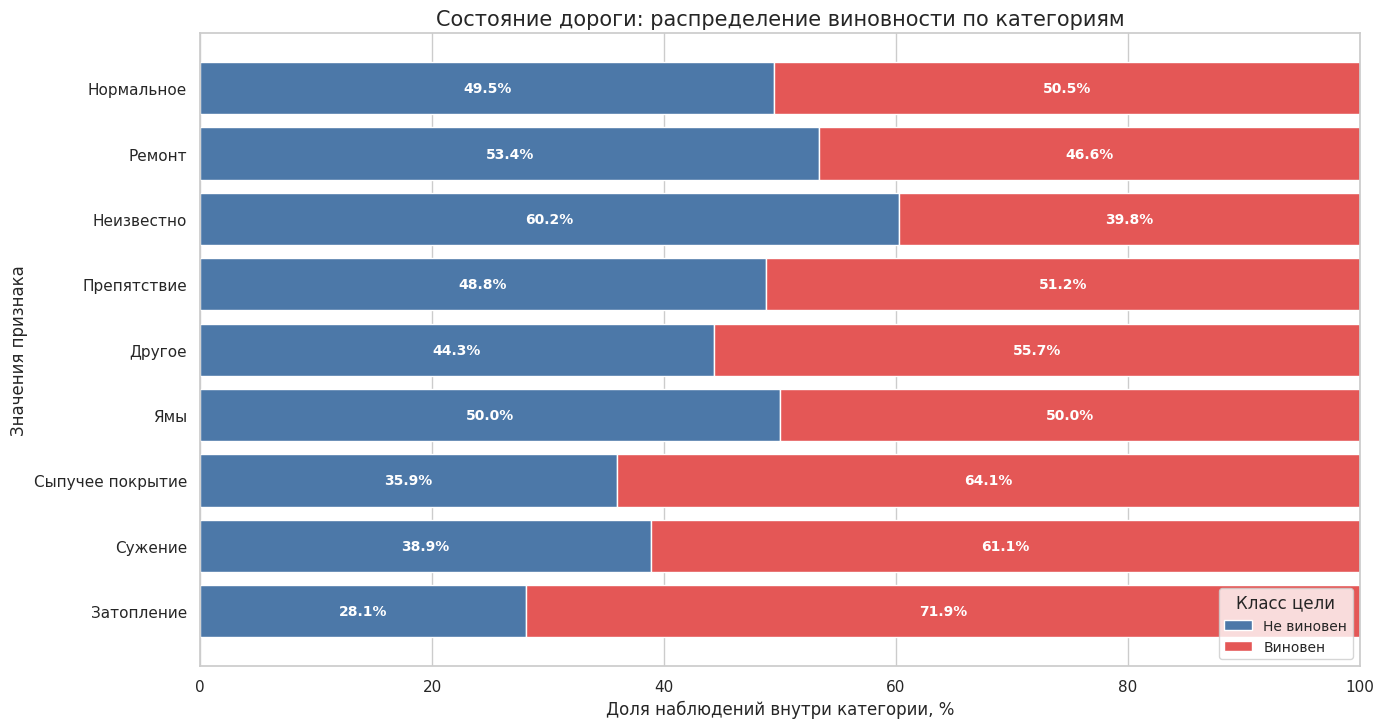

In [19]:
plot_categorical_by_target(df, 'road_condition_1', labels_ru=feature_labels_ru)

Нормальное состояние дороги почти полностью определяет форму распределения, а большинство остальных категорий слишком редки. При затоплении, сыпучем покрытии и сужении доля виновных выше, однако такие наблюдения немногочисленны. Вывод по признаку есть, но он менее устойчив, чем по состоянию водителя.

#### 4.2.14. Освещение

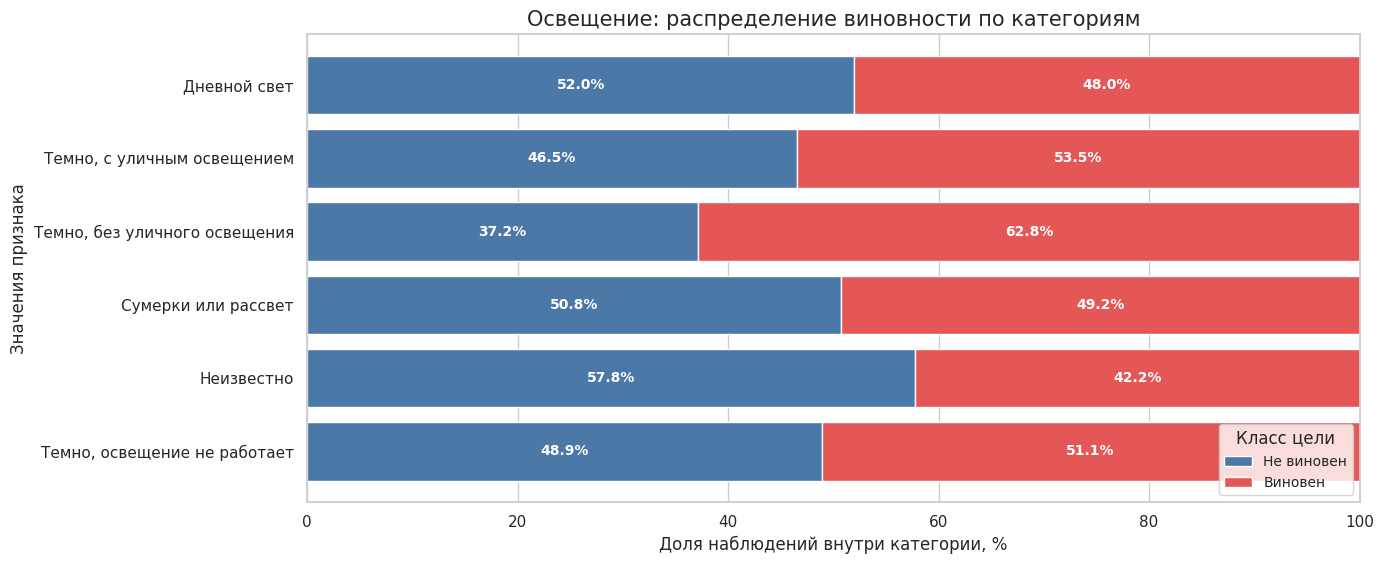

In [20]:
plot_categorical_by_target(df, 'lighting', labels_ru=feature_labels_ru)

Освещение даёт понятный градиент: днём доля виновных ниже, в темноте с работающим освещением выше, а без уличного света — ещё выше. Признак выглядит информативным и логично связан с видимостью. По силе сигнала он всё же уступает состоянию водителя и последующим характеристикам аварии.

#### 4.2.15. Средство регулирования

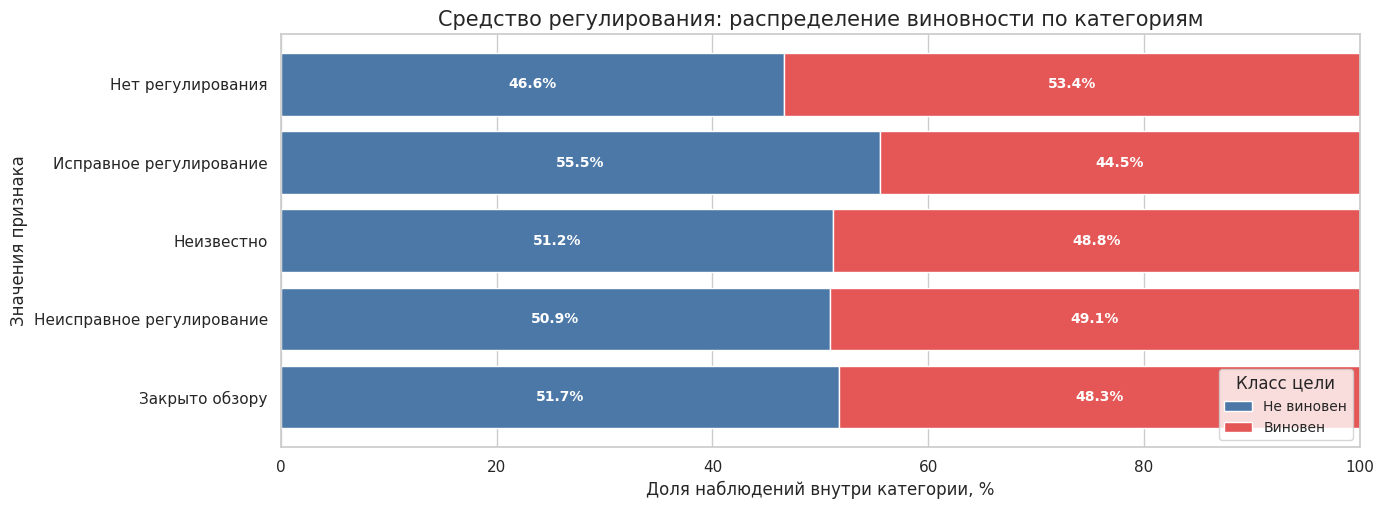

In [21]:
plot_categorical_by_target(df, 'control_device', labels_ru=feature_labels_ru)

Там, где регулирования нет, класс 1 встречается заметно чаще, чем при исправных средствах. Остальные категории очень малы по объёму, поэтому основная информация здесь сосредоточена в противопоставлении наличия и отсутствия регулирования. Признак полезен, но его сигнал умеренный.

#### 4.2.17. Тип автомобиля

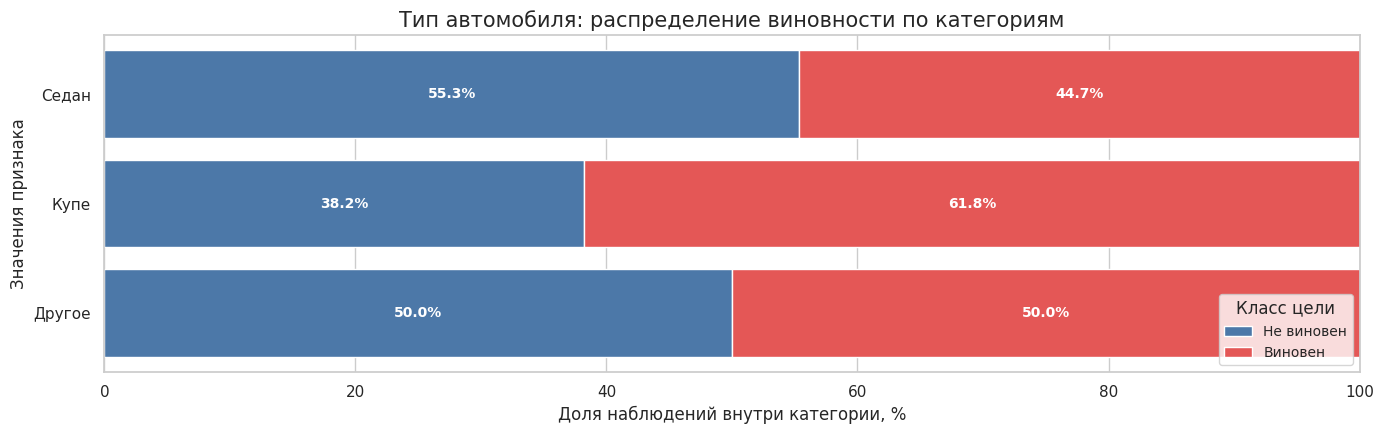

In [22]:
plot_categorical_by_target(df, 'vehicle_type', labels_ru=feature_labels_ru)

Купе заметно чаще связано с классом 1, чем седан. Разница видна на крупных группах и поэтому выглядит устойчивой. Но признак почти полностью сводится к сравнению двух массовых типов кузова и уступает по силе более прямым индикаторам состояния водителя.

#### 4.2.18. Коробка передач

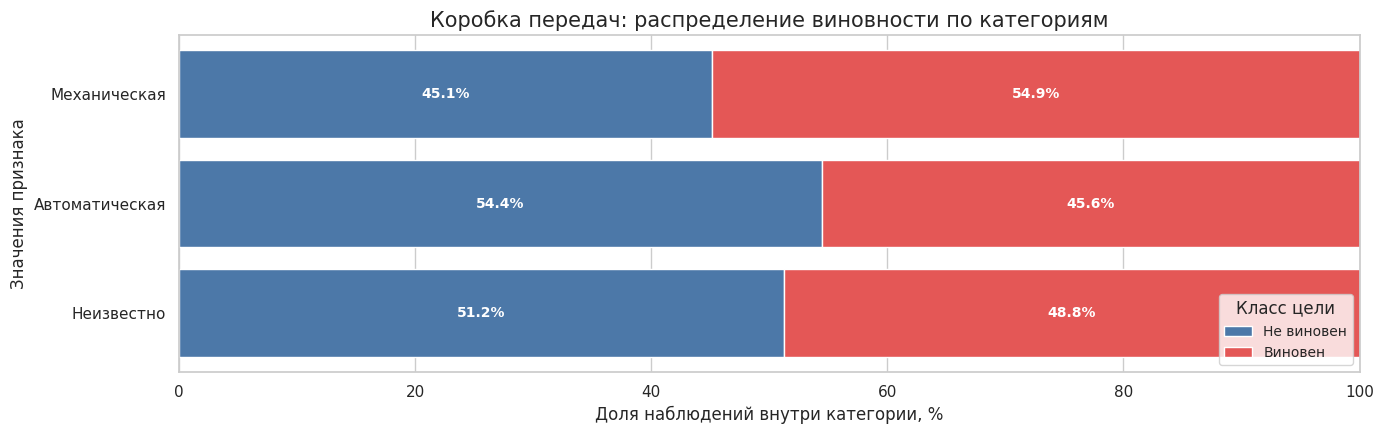

In [23]:
plot_categorical_by_target(df, 'vehicle_transmission', labels_ru=feature_labels_ru)

Для механической коробки доля класса 1 выше, чем для автоматической. Разница заметна на больших группах и не выглядит случайной. При этом она, скорее всего, отражает сопутствующие характеристики водителя и автомобиля, а не самостоятельный причинный эффект.

#### 4.2.19. Возраст автомобиля

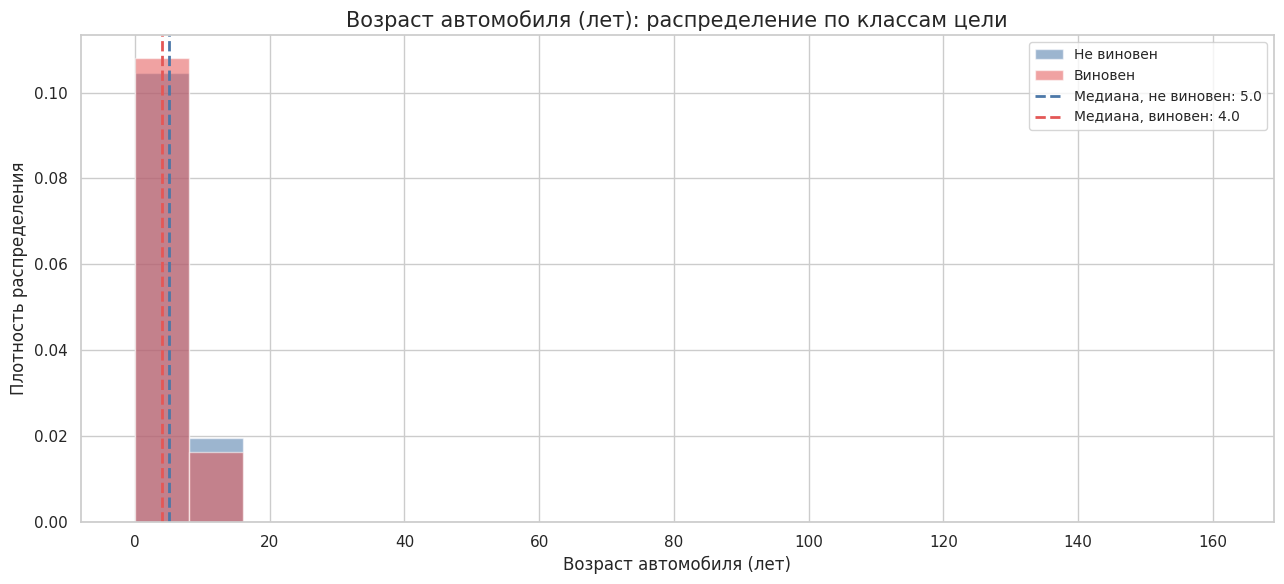

In [24]:
plot_numerical_by_target(df, 'vehicle_age', labels_ru=feature_labels_ru)

Распределения сильно перекрываются, хотя у класса 1 медиана немного ниже и масса наблюдений чуть сильнее смещена к более новым машинам. Связь заметна, но остаётся слабой и нелинейной. Один этот признак плохо разделяет классы и требует сочетания с другими факторами.

#### 4.2.20. Час суток

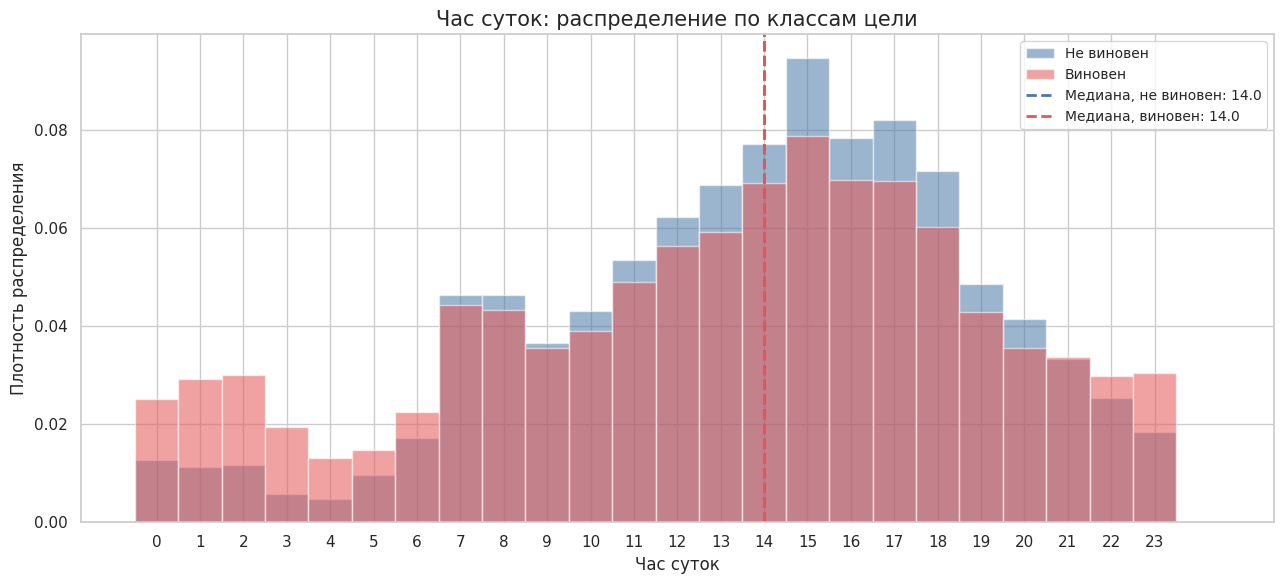

In [25]:
plot_numerical_by_target(
    df,
    'hour_of_day',
    labels_ru=feature_labels_ru,
    bins=np.arange(-0.5, 24.6, 1),
    xticks=np.arange(0, 24, 1),
)

Самый выраженный сдвиг виден ночью и ранним утром: в эти часы доля класса 1 заметно выше, чем днём и вечером. Значит, само время поездки действительно добавляет полезный сигнал и может работать как допустимый прокси для усталости, плохой видимости и снижения внимания.

#### 4.2.21. Часть суток

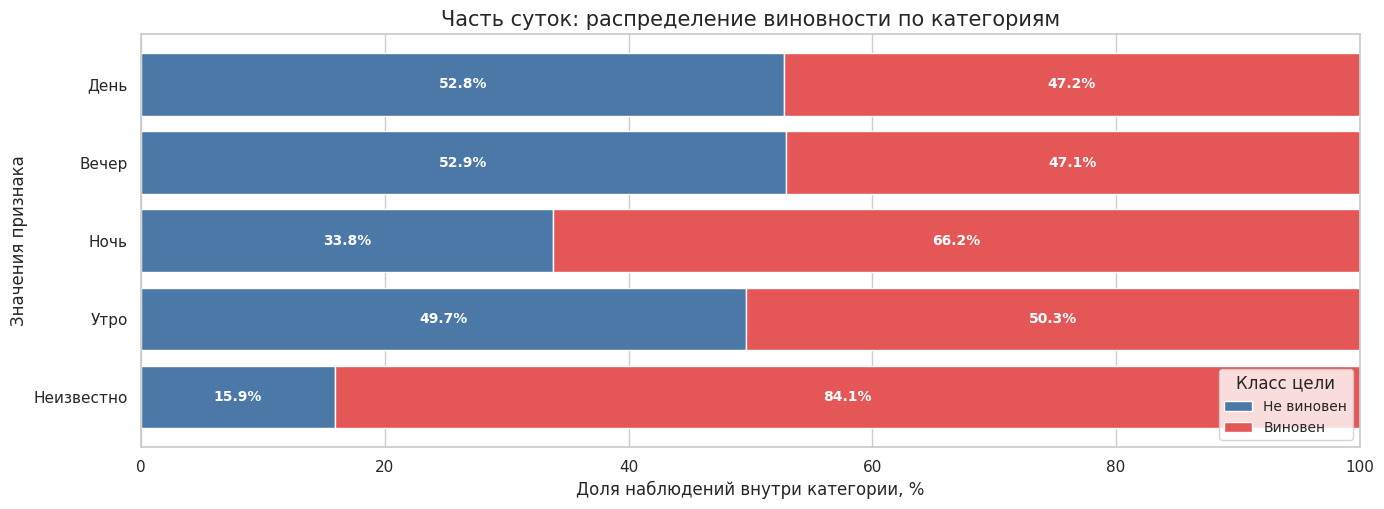

In [26]:
plot_categorical_by_target(df, 'time_bucket', labels_ru=feature_labels_ru)

Агрегация по частям суток подтверждает предыдущий график: ночь выделяется как самый рискованный интервал, тогда как день и вечер ближе к нейтральному распределению. Такой признак удобен тем, что проще объясняется бизнесу и устойчивее к локальным всплескам по отдельным часам.

#### 4.2.22. Месяц

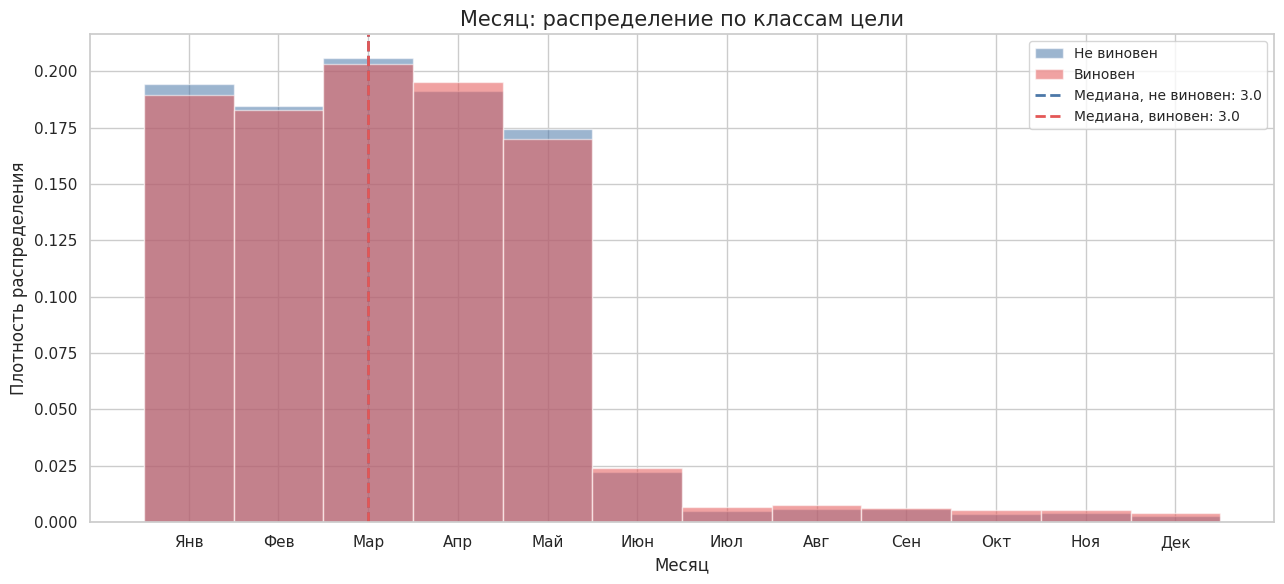

In [27]:
plot_numerical_by_target(
    df,
    'month',
    labels_ru=feature_labels_ru,
    bins=np.arange(0.5, 12.6, 1),
    xticks=np.arange(1, 13),
    xticklabels=['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'],
)

Календарный эффект есть, но он слабее, чем у времени суток: в начале года классы почти сбалансированы, а ближе к концу года доля виновных растёт. При этом поздние месяцы представлены заметно меньшим числом наблюдений, поэтому признак стоит воспринимать как вспомогательный контекст, а не как основной фактор.

#### 4.2.23. Выходной день

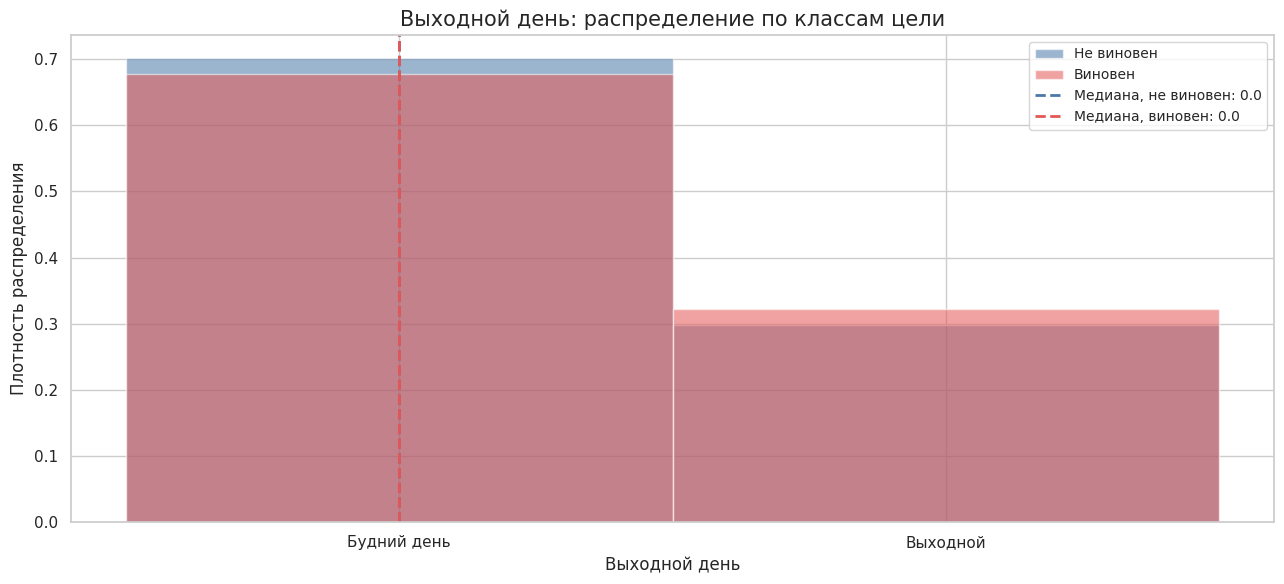

In [28]:
plot_numerical_by_target(
    df,
    'is_weekend',
    labels_ru=feature_labels_ru,
    bins=np.arange(-0.5, 2.0, 1),
    xticks=[0, 1],
    xticklabels=['Будний день', 'Выходной'],
)

В выходные доля класса 1 немного выше, чем в будни, но разница здесь умеренная. Этот признак полезен как недорогой фоновый сигнал: сам по себе он слаб, зато в сочетании с часом поездки помогает точнее описывать рискованные сценарии.

#### 4.2.23. Использование телефона

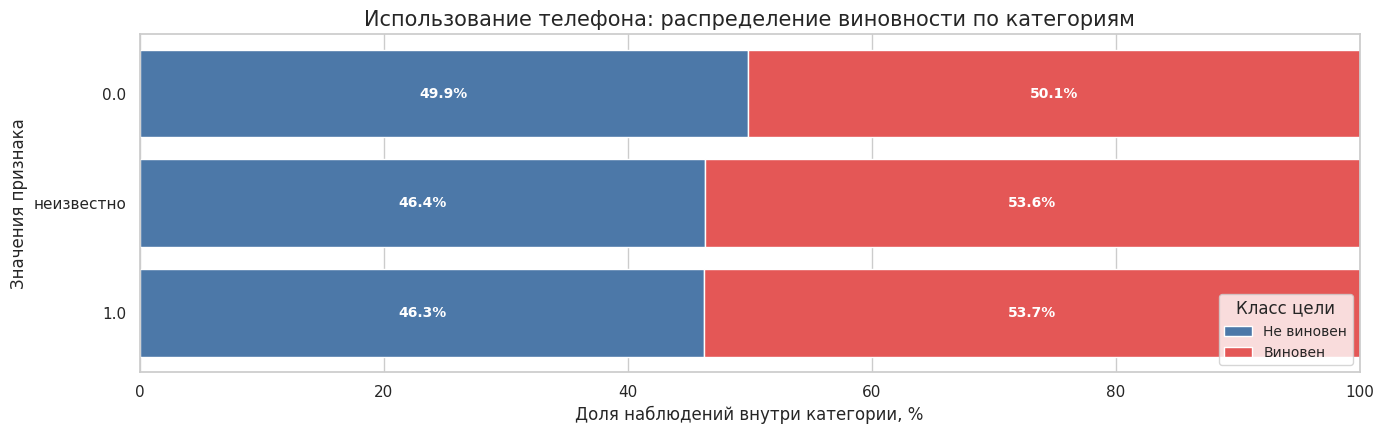

In [29]:
plot_categorical_by_target(df, 'cellphone_in_use', labels_ru=feature_labels_ru)

Признак `cellphone_in_use` известен компании до поездки, так как она знает оборудование своих автомобилей. Разница между классами умеренная, но признак допустим для модели.

#### 4.2.24. Тип местоположения

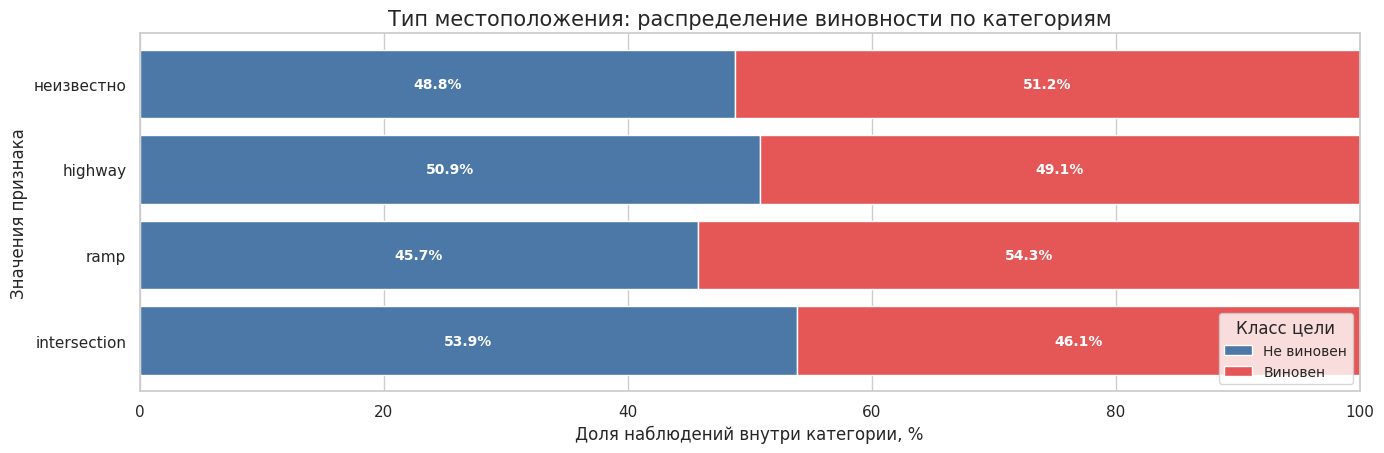

In [30]:
plot_categorical_by_target(df, 'location_type', labels_ru=feature_labels_ru)

Тип местоположения (`location_type`) можно просчитать при построении маршрута перед поездкой. На съездах и трассах доля виновных отличается от перекрёстков, что полезно для модели.

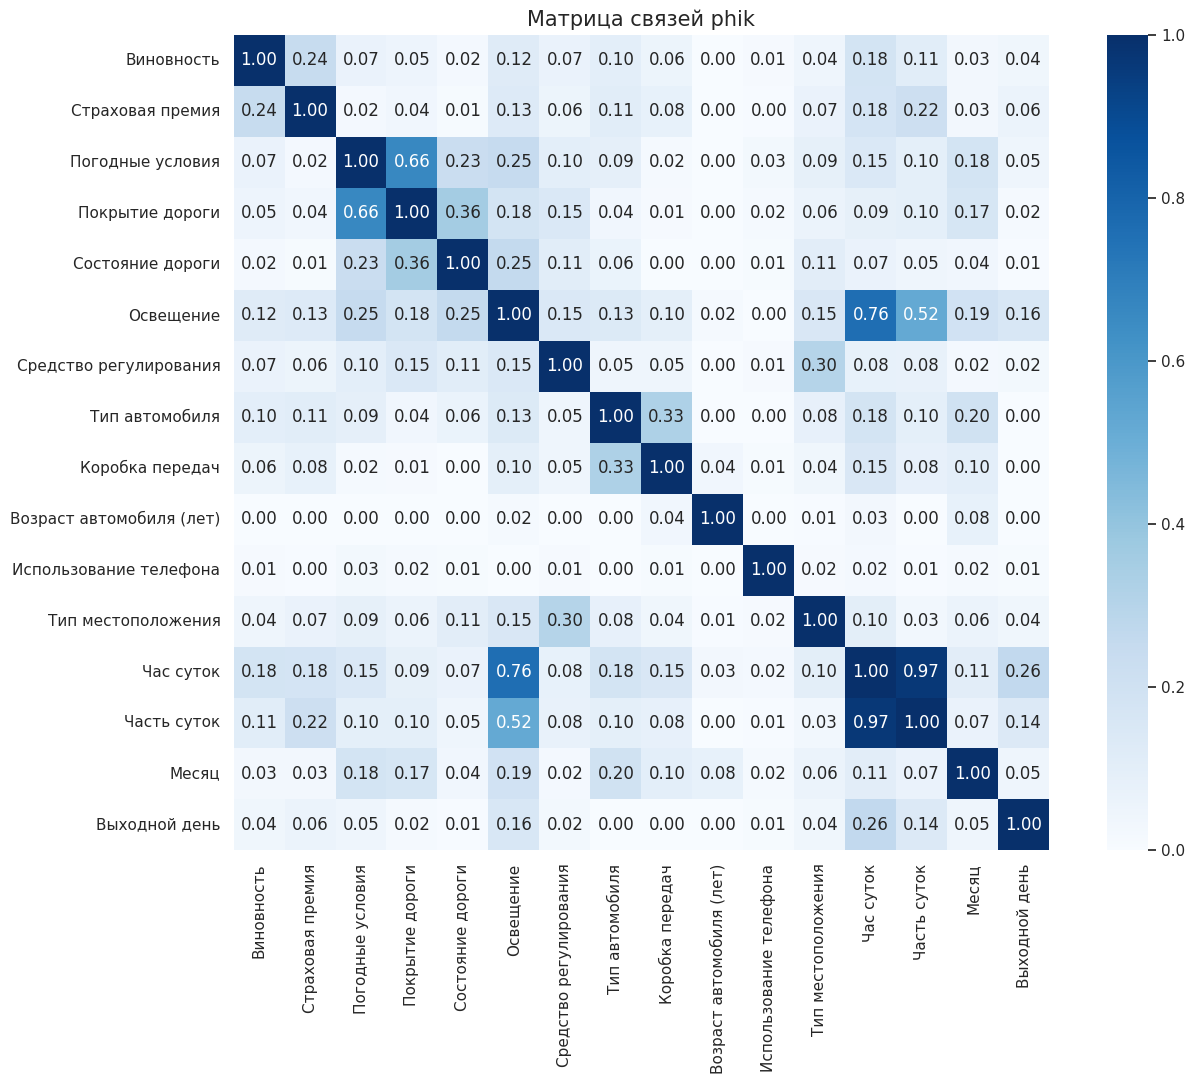

**Самые сильные связи с целевой переменной**

,phik с целью
Страховая премия,0.243748
Час суток,0.183075
Освещение,0.123562
Часть суток,0.110122
Тип автомобиля,0.097695
Погодные условия,0.068287
Средство регулирования,0.067907
Коробка передач,0.055528
Покрытие дороги,0.053600
Тип местоположения,0.043787


**Пары с высокой мультиколлинеарностью**

,признак_1,признак_2,phik
0,Освещение,Час суток,0.758
1,Час суток,Часть суток,0.967


In [31]:
df_for_phik = df[
    [
        "at_fault", "insurance_premium", "weather_1",
        "road_surface", "road_condition_1", "lighting", "control_device",
        "vehicle_type", "vehicle_transmission", "vehicle_age",
        "cellphone_in_use", "location_type",
        "hour_of_day", "time_bucket", "month", "is_weekend",
    ]
].copy()

for col in df_for_phik.columns:
    if col in {"at_fault", "is_weekend"}:
        df_for_phik[col] = df_for_phik[col].astype("Int64").astype("string")
    elif pd.api.types.is_object_dtype(df_for_phik[col]) or pd.api.types.is_string_dtype(df_for_phik[col]) or str(df_for_phik[col].dtype) == "category":
        df_for_phik[col] = df_for_phik[col].astype("string").fillna("неизвестно")

for col in ["insurance_premium", "vehicle_age", "hour_of_day", "month"]:
    df_for_phik[col] = df_for_phik[col].fillna(df_for_phik[col].median())

phik_matrix = df_for_phik.phik_matrix(
    interval_cols=["insurance_premium", "vehicle_age"]
)
phik_matrix_ru = phik_matrix.rename(index=feature_labels_ru, columns=feature_labels_ru)

target_correlations = (
    phik_matrix["at_fault"].drop("at_fault")
    .sort_values(ascending=False)
    .rename(index=feature_labels_ru)
    .to_frame("phik с целью")
)

multicollinearity_pairs = []
for left_index, left_col in enumerate(phik_matrix.columns):
    for right_col in phik_matrix.columns[left_index + 1:]:
        score = phik_matrix.loc[left_col, right_col]
        if score > 0.7:
            multicollinearity_pairs.append({
                "признак_1": feature_labels_ru.get(left_col, left_col),
                "признак_2": feature_labels_ru.get(right_col, right_col),
                "phik": round(float(score), 3),
            })

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(phik_matrix_ru, annot=True, fmt=".2f", cmap="Blues", ax=ax, square=True, vmin=0, vmax=1)
ax.set_title("Матрица связей phik")
plt.tight_layout()
plt.show()

display(Markdown("**Самые сильные связи с целевой переменной**"))
display(target_correlations.head(12))
display(Markdown("**Пары с высокой мультиколлинеарностью**"))
display(pd.DataFrame(multicollinearity_pairs))

In [32]:
kept_original_features = [
    'insurance_premium', 'weather_1',
    'road_surface', 'road_condition_1', 'lighting', 'control_device',
    'vehicle_type', 'vehicle_transmission', 'vehicle_age',
    'cellphone_in_use', 'location_type',
]
kept_temporal_features = ['hour_of_day', 'time_bucket', 'month', 'is_weekend']
kept_all_features = kept_original_features + kept_temporal_features

kept_target_correlations = (
    phik_matrix.loc[kept_all_features, 'at_fault']
    .sort_values(ascending=False)
    .rename(index=feature_labels_ru)
    .to_frame('phik с целью')
)

kept_multicollinearity_rows = []
for left_index, left_feature in enumerate(kept_all_features):
    for right_feature in kept_all_features[left_index + 1:]:
        score = float(phik_matrix.loc[left_feature, right_feature])
        if score > 0.7:
            kept_multicollinearity_rows.append({
                'признак_1': feature_labels_ru.get(left_feature, left_feature),
                'признак_2': feature_labels_ru.get(right_feature, right_feature),
                'phik': round(score, 3),
            })

kept_multicollinearity = pd.DataFrame(kept_multicollinearity_rows)
top_kept_features = ', '.join(
    f'`{name}` ({score:.2f})'
    for name, score in kept_target_correlations['phik с целью'].head(6).items()
)

display(Markdown(f'Полезный сигнал распределён между {len(kept_all_features)} признаками. Среди них наиболее заметны {top_kept_features}.'))
display(Markdown('**Связи оставленных признаков с целевой переменной**'))
display(kept_target_correlations.round(3))

if not kept_multicollinearity.empty:
    display(Markdown('**Сильные связи внутри оставленного набора**'))
    display(kept_multicollinearity)

Полезный сигнал распределён между 15 признаками. Среди них наиболее заметны `Страховая премия` (0.24), `Час суток` (0.18), `Освещение` (0.12), `Часть суток` (0.11), `Тип автомобиля` (0.10), `Погодные условия` (0.07).

**Связи оставленных признаков с целевой переменной**

,phik с целью
Страховая премия,0.244
Час суток,0.183
Освещение,0.124
Часть суток,0.110
Тип автомобиля,0.098
Погодные условия,0.068
Средство регулирования,0.068
Коробка передач,0.056
Покрытие дороги,0.054
Тип местоположения,0.044


**Сильные связи внутри оставленного набора**

,признак_1,признак_2,phik
0,Освещение,Час суток,0.758
1,Час суток,Часть суток,0.967


#### 4.3. Итоговый набор признаков

Для моделирования оставляем 9 исходных признаков и 4 временных. Послесобытийные поля исключены на этапе SQL-запроса.

<div class="alert alert-success">
<b>👍 Успех:</b> Данные исследованы и обработаны, все готово к обучению моделей!
</div>

#### 4.4. Таблица для моделирования

In [33]:
RANDOM_STATE = 42
FEATURES_CAT = [
    'weather_1', 'road_surface', 'road_condition_1',
    'lighting', 'control_device',
    'vehicle_type', 'vehicle_transmission',
    'cellphone_in_use', 'location_type',
    'time_bucket',
    'hour_of_day', 'month', 'is_weekend',
]
FEATURES_NUM = [
    'insurance_premium', 'vehicle_age',
]
TARGET = 'at_fault'

model_df = df[['case_id', TARGET] + FEATURES_CAT + FEATURES_NUM].copy()

# Приводим hour_of_day, month, is_weekend к строковому типу для категориальной обработки
for col in ['hour_of_day', 'month', 'is_weekend']:
    model_df[col] = model_df[col].fillna(-1).astype(int).astype(str)
    model_df.loc[model_df[col] == '-1', col] = np.nan

missing_share = (
    model_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename('доля пропусков')
    .to_frame()
)

display(Markdown(f"**Размер таблицы для моделирования: {model_df.shape[0]:,} строк и {model_df.shape[1]} столбцов**".replace(",", " ")))
display(model_df.head())
display(missing_share)

**Размер таблицы для моделирования: 56 232 строк и 17 столбцов**

,case_id,at_fault,weather_1,road_surface,road_condition_1,lighting,control_device,vehicle_type,vehicle_transmission,cellphone_in_use,location_type,time_bucket,hour_of_day,month,is_weekend,insurance_premium,vehicle_age
0,5600850,0,clear,dry,normal,daylight,none,sedan,auto,0.0,highway,день,12,4,0,NaN,NaN
1,5600885,1,clear,dry,normal,dark with street lights,none,sedan,auto,0.0,NaN,ночь,22,4,0,43.0,8.0
2,5600893,1,clear,dry,normal,dark with no street lights,none,sedan,auto,0.0,NaN,ночь,0,4,1,38.0,6.0
3,5603123,1,cloudy,wet,normal,daylight,none,sedan,auto,0.0,highway,день,14,4,0,20.0,11.0
4,5455644,1,cloudy,dry,normal,daylight,none,sedan,manual,0.0,ramp,день,15,1,0,22.0,3.0


,доля пропусков
location_type,0.539017
cellphone_in_use,0.079457
vehicle_age,0.030107
vehicle_transmission,0.015276
insurance_premium,0.009728
road_surface,0.006189
road_condition_1,0.004428
control_device,0.003823
weather_1,0.002988
lighting,0.002739


In [34]:
X = model_df[FEATURES_CAT + FEATURES_NUM].copy()
y = model_df[TARGET].copy()
groups = model_df['case_id'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(model_df, model_df[TARGET], groups=model_df['case_id']))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_train = groups.iloc[train_idx].reset_index(drop=True)
groups_test = groups.iloc[test_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    {
        'выборка': ['Обучающая', 'Тестовая'],
        'строк': [len(X_train), len(X_test)],
        'уникальных дел': [groups_train.nunique(), groups_test.nunique()],
        'доля at_fault=1': [
            y_train.mean().round(4),
            y_test.mean().round(4),
        ],
    }
)
display(Markdown("**Разбиение данных (80/20 по группам case_id):**"))
display(split_summary)


**Разбиение данных (80/20 по группам case_id):**

,выборка,строк,уникальных дел,доля at_fault=1
0,Обучающая,45034,35865,0.5049
1,Тестовая,11198,8967,0.5033


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> 'hour_of_day', 'month', 'is_weekend' - категориальные признаки</s>
</div>

Классы в рабочем наборе практически сбалансированы: доли близки к соотношению 50/50 и в обучающей, и в тестовой части после разбиения 80/20. Поэтому вручную выравнивать классы не нужно: это только усложнит интерпретацию и может добавить лишний шум.

#### 4.7. Итог по шагу 4

Итоговый набор: 9 исходных + 4 временных признака, все доступны до поездки. Послесобытийные признаки исключены на этапе SQL-запроса, а в моделирование оставлены только полные годы из диапазона начиная с 2012.


#### 4.5. Конвейер предобработки

In [35]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), FEATURES_NUM),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first')),
    ]), FEATURES_CAT),
])

display(Markdown("**Категориальные признаки** — пропуски заполняются модой"))
display(pd.DataFrame({'признак': FEATURES_CAT}))
display(Markdown("**Числовые признаки** — пропуски заполняются медианой"))
display(pd.DataFrame({'признак': FEATURES_NUM}))

**Категориальные признаки** — пропуски заполняются модой

,признак
0,weather_1
1,road_surface
2,road_condition_1
3,lighting
4,control_device
5,vehicle_type
6,vehicle_transmission
7,cellphone_in_use
8,location_type
9,time_bucket


**Числовые признаки** — пропуски заполняются медианой

,признак
0,insurance_premium
1,vehicle_age


#### 4.6. Разбиение на обучающую и тестовую выборки

<div class="alert alert-danger">
<b>😔 Необходимо исправить V2:</b> В проекте нужны только 2 выборки - обучающая и тестовая, валидационная не нужна
</div>

<div class="alert alert-info">
<b>🎓 Комментарий студента:</b> Исправлено: валидационная выборка убрана. Данные разбиты только на обучающую (80%) и тестовую (20%) выборки через GroupShuffleSplit. Для подбора гиперпараметров используется 5-фолдовая кросс-валидация на обучающей выборке. Для нейросети (MLP) ранняя остановка контролируется на внутреннем holdout, выделенном только из обучающей части. Тестовая выборка используется единственный раз — для финальной оценки лучшей модели в шаге 6.
</div>

Классы в рабочем наборе практически сбалансированы: доли близки к соотношению 50/50 и в обучающей, и в тестовой части после разбиения 80/20. Поэтому вручную выравнивать классы не нужно: это только усложнит интерпретацию и может добавить лишний шум.

#### 4.7. Итог по шагу 4

Итоговый набор: 9 исходных + 4 временных признака, все доступны до поездки. Послесобытийные признаки исключены на этапе SQL-запроса, а в моделирование оставлены только полные годы из диапазона начиная с 2012.

## Шаг 5. Моделирование

После отбора признаков можно переходить к построению моделей. Дальше сравним три подхода: линейную модель как базовый ориентир, CatBoost как более гибкий ансамбль и полносвязную нейросеть как вариант, способный улавливать нелинейные сочетания состояния водителя, погодно-дорожного контекста, характеристик автомобиля и времени поездки.

#### 5.1. Метрика качества

В качестве основной метрики зафиксируем `Fβ` при `β = 1.25`. Такая настройка даёт примерно баланс 60/40 в пользу полноты: сервису важнее не пропустить рискованного водителя, чем любой ценой сократить число ложных тревог.

Бизнес-смысл здесь не сводится только к деньгам. Если система пропускает действительно рискованную поездку, пользователь получает аварийный сценарий, теряет доверие к сервису и начинает сомневаться в самой идее безопасного каршеринга. Поэтому лёгкий сдвиг в сторону полноты для этой задачи оправдан.

<div class="alert alert-success">
<b>👍 Успех:</b> Отличный выбор метрики!
</div>

In [36]:
warnings.filterwarnings(
    "ignore",
    message=".*'penalty' was deprecated.*",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message=".*Inconsistent values: penalty=.*",
    category=UserWarning,
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

BETA = 1.25
cv_splits = list(GroupKFold(n_splits=5).split(X_train, y_train, groups=groups_train))
model_results = []
model_artifacts = {}
model_predictions = {}

def calc_fbeta(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=BETA, zero_division=0)

def evaluate_scores(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        'f_beta': calc_fbeta(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'y_pred': y_pred,
    }

def add_model_result(model_name, metrics, elapsed_seconds):
    model_results.append(
        {
            'Модель': model_name,
            'Fβ (β=1.25)': metrics['f_beta'],
            'ROC-AUC': metrics['roc_auc'],
            'Время обучения, с': elapsed_seconds,
        }
    )

#### 5.2. Логистическая регрессия и подбор параметров

In [37]:
def objective_logreg(trial):
    C = trial.suggest_float('C', 1e-4, 100.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0) if penalty == 'elasticnet' else None

    model = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', LogisticRegression(
            C=C, penalty=penalty, solver='saga',
            l1_ratio=l1_ratio, max_iter=5000, random_state=RANDOM_STATE,
        )),
    ])

    scores = cross_val_score(model, X_train, y_train, cv=cv_splits, scoring='roc_auc', n_jobs=1)
    return scores.mean()

lr_start = time.perf_counter()
study_lr = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_lr.optimize(objective_logreg, n_trials=20, show_progress_bar=False)

best_lr_params = study_lr.best_params.copy()
best_lr_l1_ratio = best_lr_params.get('l1_ratio') if best_lr_params['penalty'] == 'elasticnet' else None
best_lr_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LogisticRegression(
        C=best_lr_params['C'], penalty=best_lr_params['penalty'], solver='saga',
        l1_ratio=best_lr_l1_ratio, max_iter=5000, random_state=RANDOM_STATE,
    )),
])

lr_cv_fbeta = []
lr_cv_roc_auc = []
for train_fold_idx, val_fold_idx in cv_splits:
    fold_model = clone(best_lr_pipeline)
    fold_model.fit(X_train.iloc[train_fold_idx], y_train.iloc[train_fold_idx])
    fold_proba = fold_model.predict_proba(X_train.iloc[val_fold_idx])[:, 1]
    fold_pred = (fold_proba >= 0.5).astype(int)
    lr_cv_fbeta.append(calc_fbeta(y_train.iloc[val_fold_idx], fold_pred))
    lr_cv_roc_auc.append(roc_auc_score(y_train.iloc[val_fold_idx], fold_proba))

lr_mean_fbeta = np.mean(lr_cv_fbeta)
lr_mean_roc_auc = np.mean(lr_cv_roc_auc)
lr_elapsed = time.perf_counter() - lr_start

model_results.append({
    'Модель': 'Логистическая регрессия',
    'Fβ (β=1.25)': lr_mean_fbeta,
    'ROC-AUC': lr_mean_roc_auc,
    'Время обучения, с': lr_elapsed,
})
model_artifacts['Логистическая регрессия'] = {
    'kind': 'pipeline',
    'pipeline_template': best_lr_pipeline,
    'threshold': 0.5,
}

display(Markdown(f"**Лучший средний ROC-AUC по кросс-валидации: {lr_mean_roc_auc:.4f}**"))
display(pd.DataFrame([study_lr.best_params]))
display(pd.DataFrame([{
    'Fβ (β=1.25) CV': lr_mean_fbeta,
    'ROC-AUC CV': lr_mean_roc_auc,
    'Время, с': lr_elapsed,
}]).round(4))

**Лучший средний ROC-AUC по кросс-валидации: 0.6468**

,C,penalty,l1_ratio
0,0.121733,elasticnet,0.170524


,Fβ (β=1.25) CV,ROC-AUC CV,"Время, с"
0,0.5875,0.6468,654.0244


<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Тестовые данные не используются на этом этапе (из обучения моделей ниже это тоже нужно убрать). Модели сравниваются на метрике кроссвалидации, и только одна лучшая модель проверяется на тестовых данных</s>
</div>

<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Исправлено: модели сравниваются по кросс-валидации, тестовая выборка используется только для финальной проверки лучшей модели.</div>

Логистическая регрессия задаёт базовую планку качества. Все метрики получены через 5-фолдовую кросс-валидацию.

#### 5.3. CatBoost и подбор параметров

In [38]:
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'loss_function': 'Logloss',
        'random_seed': RANDOM_STATE,
        'verbose': 0,
        'allow_writing_files': False,
    }

    model = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', CatBoostClassifier(**params)),
    ])

    scores = cross_val_score(model, X_train, y_train, cv=cv_splits, scoring='roc_auc', n_jobs=1)
    return scores.mean()

cb_start = time.perf_counter()
study_cb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_cb.optimize(objective_catboost, n_trials=50, show_progress_bar=False)

best_cb_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', CatBoostClassifier(
        iterations=study_cb.best_params['iterations'],
        depth=study_cb.best_params['depth'],
        learning_rate=study_cb.best_params['learning_rate'],
        l2_leaf_reg=study_cb.best_params['l2_leaf_reg'],
        border_count=study_cb.best_params['border_count'],
        loss_function='Logloss', random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    )),
])

cb_cv_fbeta = []
cb_cv_roc_auc = []
for train_fold_idx, val_fold_idx in cv_splits:
    fold_model = clone(best_cb_pipeline)
    fold_model.fit(X_train.iloc[train_fold_idx], y_train.iloc[train_fold_idx])
    fold_proba = fold_model.predict_proba(X_train.iloc[val_fold_idx])[:, 1]
    fold_pred = (fold_proba >= 0.5).astype(int)
    cb_cv_fbeta.append(calc_fbeta(y_train.iloc[val_fold_idx], fold_pred))
    cb_cv_roc_auc.append(roc_auc_score(y_train.iloc[val_fold_idx], fold_proba))

cb_mean_fbeta = np.mean(cb_cv_fbeta)
cb_mean_roc_auc = np.mean(cb_cv_roc_auc)
cb_elapsed = time.perf_counter() - cb_start

model_results.append({
    'Модель': 'CatBoost',
    'Fβ (β=1.25)': cb_mean_fbeta,
    'ROC-AUC': cb_mean_roc_auc,
    'Время обучения, с': cb_elapsed,
})
model_artifacts['CatBoost'] = {
    'kind': 'pipeline',
    'pipeline_template': best_cb_pipeline,
    'threshold': 0.5,
}

display(Markdown(f"**Лучший средний ROC-AUC по кросс-валидации: {cb_mean_roc_auc:.4f}**"))
display(pd.DataFrame([study_cb.best_params]))
display(pd.DataFrame([{
    'Fβ (β=1.25) CV': cb_mean_fbeta,
    'ROC-AUC CV': cb_mean_roc_auc,
    'Время, с': cb_elapsed,
}]).round(4))

**Лучший средний ROC-AUC по кросс-валидации: 0.6798**

,iterations,depth,learning_rate,l2_leaf_reg,border_count
0,629,7,0.021935,3.885097,83


,Fβ (β=1.25) CV,ROC-AUC CV,"Время, с"
0,0.6186,0.6798,654.8812


CatBoost здесь полезен как проверка более гибкой модели. Все метрики получены через 5-фолдовую кросс-валидацию.

#### 5.4. Полносвязная нейросеть на PyTorch

Для нейросети проверим пять заранее зафиксированных архитектур. Раннюю остановку будем контролировать на внутренней контрольной части, выделенной только из обучающей выборки. Внешний тест при этом остаётся полностью нетронутым до финальной оценки лучшей модели.

Для ранней остановки используется **экспоненциальное скользящее среднее (EMA)** метрики на внутренней контрольной части. EMA отслеживает затухающее улучшение модели: если за последние 10 эпох прирост качества составляет менее 1%, обучение прекращается. Это позволяет остановить тренировку до переобучения, не теряя полезных эпох на ранних стадиях.

In [39]:
def _to_dense(arr):
    """Convert sparse to dense if needed."""
    if scipy.sparse.issparse(arr):
        return arr.toarray()
    return arr


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

ARCHITECTURES = [
    {'name': '[128], ReLU', 'layers': [128], 'activation': 'relu'},
    {'name': '[256, 128], ReLU', 'layers': [256, 128], 'activation': 'relu'},
    {'name': '[384, 192, 96], ReLU', 'layers': [384, 192, 96], 'activation': 'relu'},
    {'name': '[256, 128, 64], Swish', 'layers': [256, 128, 64], 'activation': 'silu'},
    {'name': '[320, 160], LeakyReLU', 'layers': [320, 160], 'activation': 'leaky_relu'},
]

inner_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
inner_train_idx, inner_holdout_idx = next(inner_split.split(X_train, y_train, groups=groups_train))
X_train_inner = X_train.iloc[inner_train_idx].reset_index(drop=True)
X_holdout_inner = X_train.iloc[inner_holdout_idx].reset_index(drop=True)
y_train_inner = y_train.iloc[inner_train_idx].reset_index(drop=True)
y_holdout_inner = y_train.iloc[inner_holdout_idx].reset_index(drop=True)


def activation_factory(name):
    if name == 'relu':
        return nn.ReLU()
    if name == 'silu':
        return nn.SiLU()
    return nn.LeakyReLU(negative_slope=0.1)


class TabularMLP(nn.Module):
    def __init__(self, input_dim, layers, activation_name):
        super().__init__()
        blocks = []
        current_dim = input_dim
        for hidden_dim in layers:
            blocks.append(nn.Linear(current_dim, hidden_dim))
            blocks.append(nn.BatchNorm1d(hidden_dim))
            blocks.append(activation_factory(activation_name))
            current_dim = hidden_dim
        blocks.append(nn.Linear(current_dim, 1))
        self.network = nn.Sequential(*blocks)

    def forward(self, values):
        return self.network(values).squeeze(1)


def predict_mlp_probabilities(model, array, batch_size=4096):
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(array), batch_size):
            batch = torch.tensor(array[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(batch)
            outputs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(outputs)


def fit_mlp_trial(params, trial=None, keep_history=True):
    trial_preprocessor = clone(preprocessor)
    X_inner_train_arr = _to_dense(trial_preprocessor.fit_transform(X_train_inner)).astype(np.float32)
    X_inner_holdout_arr = _to_dense(trial_preprocessor.transform(X_holdout_inner)).astype(np.float32)

    train_targets = y_train_inner.to_numpy(dtype=np.float32)
    holdout_targets = y_holdout_inner.to_numpy(dtype=np.float32)

    architecture = ARCHITECTURES[params['architecture_idx']]
    model = TabularMLP(
        input_dim=X_inner_train_arr.shape[1],
        layers=architecture['layers'],
        activation_name=architecture['activation'],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params['learning_rate'],
        weight_decay=params['weight_decay'],
    )
    criterion = nn.BCEWithLogitsLoss()

    train_dataset = TensorDataset(
        torch.tensor(X_inner_train_arr, dtype=torch.float32),
        torch.tensor(train_targets, dtype=torch.float32),
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=params['batch_size'],
        shuffle=True,
        drop_last=False,
    )

    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 1
    best_ema = -np.inf
    ema_metric = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, 301):
        model.train()
        for batch_values, batch_target in train_loader:
            batch_values = batch_values.to(DEVICE)
            batch_target = batch_target.to(DEVICE)
            optimizer.zero_grad()
            logits = model(batch_values)
            loss = criterion(logits, batch_target)
            loss.backward()
            optimizer.step()

        train_prob = predict_mlp_probabilities(model, X_inner_train_arr)
        holdout_prob = predict_mlp_probabilities(model, X_inner_holdout_arr)
        train_pred = (train_prob >= 0.5).astype(int)
        holdout_pred = (holdout_prob >= 0.5).astype(int)
        with torch.no_grad():
            train_logits_full = model(
                torch.tensor(X_inner_train_arr, dtype=torch.float32, device=DEVICE)
            )
            holdout_logits_full = model(
                torch.tensor(X_inner_holdout_arr, dtype=torch.float32, device=DEVICE)
            )
            train_loss = float(
                criterion(
                    train_logits_full,
                    torch.tensor(train_targets, dtype=torch.float32, device=DEVICE),
                ).item()
            )
            holdout_loss = float(
                criterion(
                    holdout_logits_full,
                    torch.tensor(holdout_targets, dtype=torch.float32, device=DEVICE),
                ).item()
            )
        train_fbeta = calc_fbeta(train_targets, train_pred)
        holdout_fbeta = calc_fbeta(holdout_targets, holdout_pred)

        ema_metric = holdout_fbeta if ema_metric is None else 0.2 * holdout_fbeta + 0.8 * ema_metric
        history.append(
            {
                'epoch': epoch,
                'train_fbeta': train_fbeta,
                'holdout_fbeta': holdout_fbeta,
                'train_loss': train_loss,
                'holdout_loss': holdout_loss,
                'ema_holdout_fbeta': ema_metric,
            }
        )

        if ema_metric > best_ema * 1.01 if best_ema > 0 else ema_metric > best_ema:
            best_ema = ema_metric
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if trial is not None:
            trial.report(float(ema_metric), step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if epochs_without_improvement >= 10:
            break

    model.load_state_dict(best_state)
    holdout_prob = predict_mlp_probabilities(model, X_inner_holdout_arr)
    holdout_metrics = evaluate_scores(holdout_targets, holdout_prob)

    return {
        'history': history if keep_history else None,
        'best_epoch': best_epoch,
        'best_ema': float(best_ema),
        'holdout_fbeta': float(holdout_metrics['f_beta']),
        'holdout_roc_auc': float(holdout_metrics['roc_auc']),
        'architecture_name': architecture['name'],
        'params': params,
    }

In [40]:
mlp_trial_runs = {}

def objective_mlp(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128, 256]),
        'architecture_idx': trial.suggest_categorical('architecture_idx', [0, 1, 2, 3, 4]),
    }
    trial_result = fit_mlp_trial(params, trial=trial, keep_history=True)
    mlp_trial_runs[trial.number] = trial_result
    return trial_result['best_ema']

mlp_start = time.perf_counter()
study_mlp = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
)
study_mlp.optimize(objective_mlp, n_trials=30, show_progress_bar=False)

best_mlp_params = study_mlp.best_params.copy()
best_mlp_trial = mlp_trial_runs[study_mlp.best_trial.number]
best_mlp_epoch = best_mlp_trial['best_epoch']
mlp_elapsed = time.perf_counter() - mlp_start

model_results.append({
    'Модель': 'Полносвязная нейросеть',
    'Fβ (β=1.25)': best_mlp_trial['holdout_fbeta'],
    'ROC-AUC': best_mlp_trial['holdout_roc_auc'],
    'Время обучения, с': mlp_elapsed,
})
model_artifacts['Полносвязная нейросеть'] = {
    'kind': 'mlp',
    'best_params': best_mlp_params,
    'best_epoch': best_mlp_epoch,
    'threshold': 0.5,
}

display(Markdown(f"**Лучшее значение сглаженного Fβ на контрольной части: {study_mlp.best_value:.4f}**"))
display(pd.DataFrame([{
    **study_mlp.best_params,
    'архитектура': best_mlp_trial['architecture_name'],
    'лучшее число эпох': best_mlp_epoch,
}]))
display(pd.DataFrame([{
    'Fβ (β=1.25) контроль': best_mlp_trial['holdout_fbeta'],
    'ROC-AUC контроль': best_mlp_trial['holdout_roc_auc'],
    'Время, с': mlp_elapsed,
}]).round(4))

**Лучшее значение сглаженного Fβ на контрольной части: 0.6480**

,learning_rate,weight_decay,batch_size,architecture_idx,архитектура,лучшее число эпох
0,0.004568,0.000232,128,0,"[128], ReLU",1


,Fβ (β=1.25) контроль,ROC-AUC контроль,"Время, с"
0,0.648,0.6636,195.8981


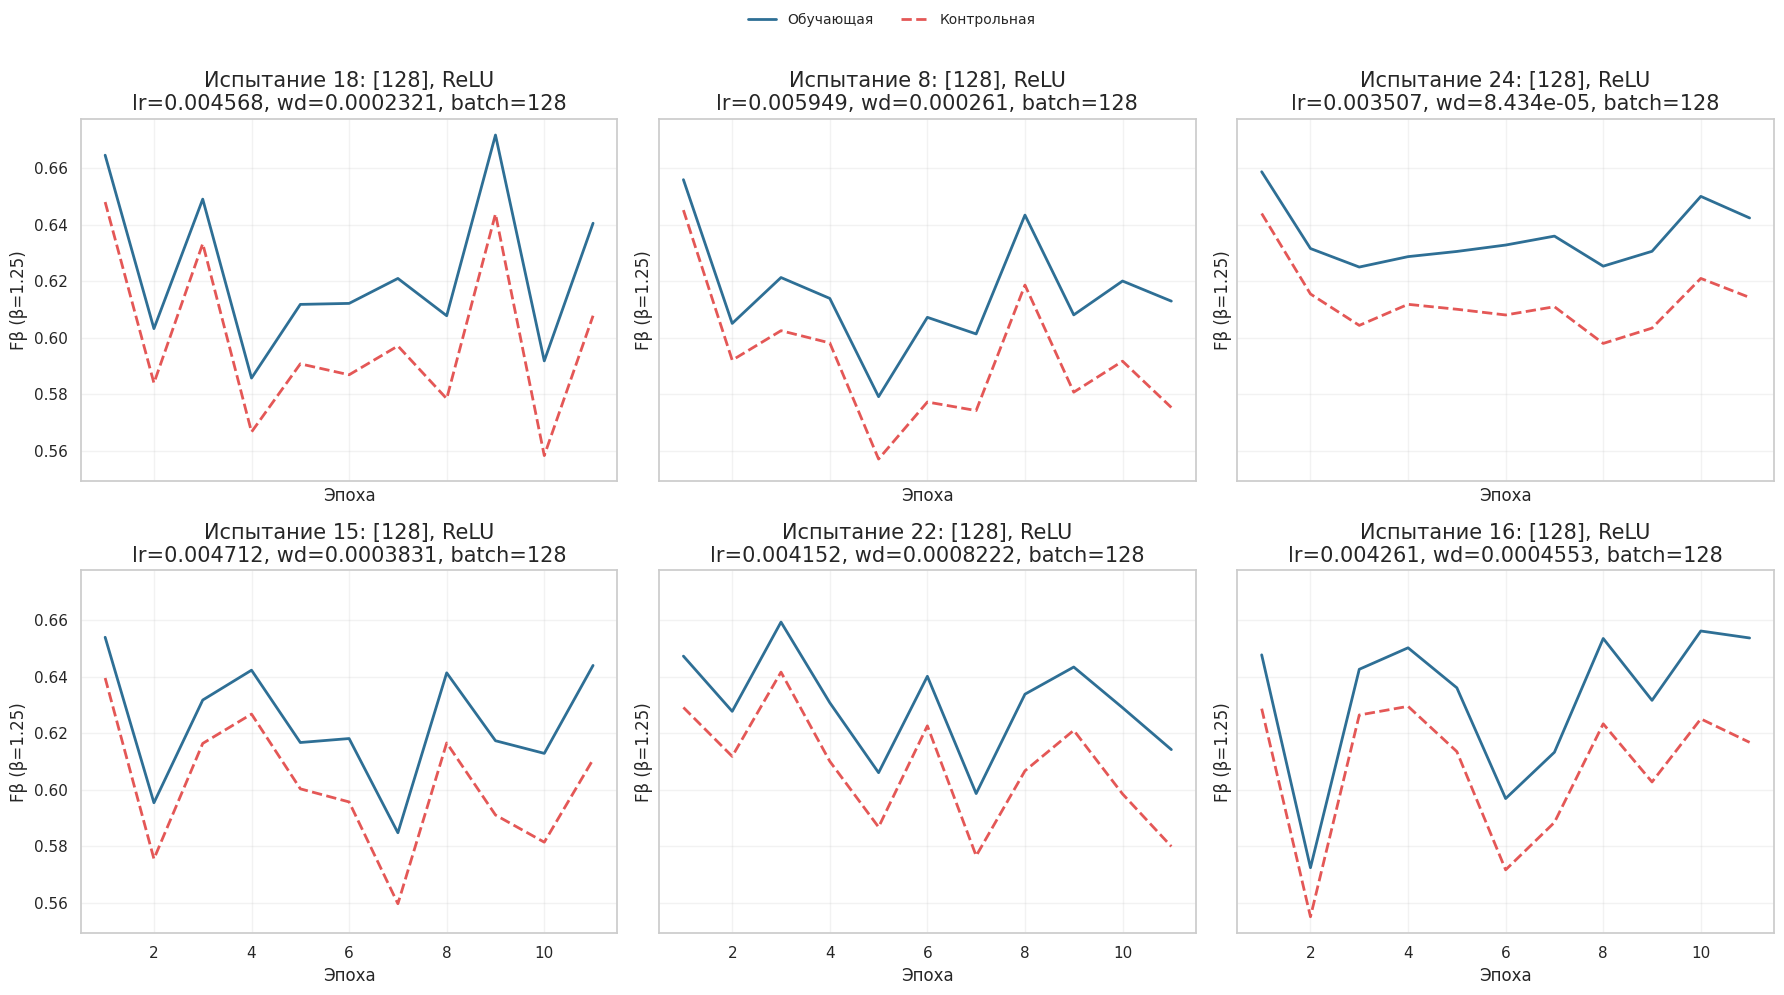

In [41]:
ranked_trials = sorted(
    mlp_trial_runs.items(),
    key=lambda item: item[1]['best_ema'],
    reverse=True,
)[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (trial_number, trial_result) in zip(axes, ranked_trials):
    history_df = pd.DataFrame(trial_result['history'])
    ax.plot(history_df['epoch'], history_df['train_fbeta'], color=MAIN_COLOR, linewidth=2, label='Обучающая')
    ax.plot(history_df['epoch'], history_df['holdout_fbeta'], color='#E45756', linewidth=2, linestyle='--', label='Контрольная')
    ax.set_title(
        f"Испытание {trial_number}: {trial_result['architecture_name']}\n"
        f"lr={trial_result['params']['learning_rate']:.4g}, wd={trial_result['params']['weight_decay']:.4g}, "
        f"batch={trial_result['params']['batch_size']}"
    )
    ax.set_xlabel('Эпоха')
    ax.set_ylabel(f'Fβ (β={BETA})')
    ax.grid(alpha=0.25)

for ax in axes[len(ranked_trials):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

У лучших прогонов нейросети качество обычно стабилизируется довольно быстро, а затем выходит на плато. Это означает, что ранняя остановка здесь действительно уместна: дополнительное число эпох не даёт заметного выигрыша и только растягивает обучение.

#### 5.5. Сравнение моделей

In [42]:
comparison_table = pd.DataFrame(model_results)
comparison_table['Время обучения'] = comparison_table['Время обучения, с'].map(lambda value: f'{value:.1f} с')
comparison_table_display = comparison_table[['Модель', 'Fβ (β=1.25)', 'ROC-AUC', 'Время обучения']].copy()
comparison_table_display = comparison_table_display.rename(columns={'Fβ (β=1.25)': 'Fβ (β=1.25) CV', 'ROC-AUC': 'ROC-AUC CV'})
comparison_table_display[['Fβ (β=1.25) CV', 'ROC-AUC CV']] = comparison_table_display[['Fβ (β=1.25) CV', 'ROC-AUC CV']].round(4)
display(comparison_table_display)

,Модель,Fβ (β=1.25) CV,ROC-AUC CV,Время обучения
0,Логистическая регрессия,0.5875,0.6468,654.0 с
1,CatBoost,0.6186,0.6798,654.9 с
2,Полносвязная нейросеть,0.6480,0.6636,195.9 с


Логистическая регрессия и CatBoost сравниваются по 5-фолдовой кросс-валидации на обучающей выборке, а для MLP ориентиром служит внутренняя контрольная часть train. После этого лучшую модель проверяю только на внешней тестовой выборке.

## Шаг 6. Оценка лучшей модели

<div class="alert alert-danger">
    <s><b>😔 Необходимо исправить:</b> Вот здесь нужно проверить лучшую модель на тестовых данных</s>
</div>

<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Исправлено: добавлена проверка лучшей модели на тестовых данных с выводом Fβ.</div>

In [43]:
ranked_models = comparison_table.sort_values(
    ['Fβ (β=1.25)', 'ROC-AUC'], ascending=False,
).reset_index(drop=True)

best_model_name = ranked_models.loc[0, 'Модель']
best_model_artifact = model_artifacts[best_model_name]

display(Markdown(f"**Лучшая модель по кросс-валидации: {best_model_name}**"))

# Обучаем лучшую модель на ВСЕХ обучающих данных и оцениваем на тестовых
if best_model_artifact['kind'] == 'pipeline':
    best_final_model = clone(best_model_artifact['pipeline_template'])
    best_final_model.fit(X_train, y_train)
    best_scores = best_final_model.predict_proba(X_test)[:, 1]
    best_pred = (best_scores >= 0.5).astype(int)
    best_metrics_test = {
        'f_beta': calc_fbeta(y_test, best_pred),
        'roc_auc': roc_auc_score(y_test, best_scores),
    }
    model_artifacts[best_model_name]['fitted_model'] = best_final_model
else:
    # MLP: обучаем на полных обучающих данных
    mlp_params = best_model_artifact['best_params']
    mlp_epochs = best_model_artifact['best_epoch']
    full_preprocessor = clone(preprocessor)
    X_train_full_arr = _to_dense(full_preprocessor.fit_transform(X_train)).astype(np.float32)
    X_test_arr = _to_dense(full_preprocessor.transform(X_test)).astype(np.float32)
    train_targets = y_train.to_numpy(dtype=np.float32)

    architecture = ARCHITECTURES[mlp_params['architecture_idx']]
    mlp_final_model = TabularMLP(
        input_dim=X_train_full_arr.shape[1],
        layers=architecture['layers'],
        activation_name=architecture['activation'],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        mlp_final_model.parameters(), lr=mlp_params['learning_rate'], weight_decay=mlp_params['weight_decay'],
    )
    criterion = nn.BCEWithLogitsLoss()
    train_dataset = TensorDataset(
        torch.tensor(X_train_full_arr, dtype=torch.float32),
        torch.tensor(train_targets, dtype=torch.float32),
    )
    train_loader = DataLoader(train_dataset, batch_size=mlp_params['batch_size'], shuffle=True, drop_last=False)

    for _ in range(mlp_epochs):
        mlp_final_model.train()
        for batch_values, batch_target in train_loader:
            batch_values = batch_values.to(DEVICE)
            batch_target = batch_target.to(DEVICE)
            optimizer.zero_grad()
            logits = mlp_final_model(batch_values)
            loss = criterion(logits, batch_target)
            loss.backward()
            optimizer.step()

    best_scores = predict_mlp_probabilities(mlp_final_model, X_test_arr)
    best_pred = (best_scores >= 0.5).astype(int)
    best_metrics_test = {
        'f_beta': calc_fbeta(y_test.to_numpy(dtype=np.float32), best_pred),
        'roc_auc': roc_auc_score(y_test.to_numpy(dtype=np.float32), best_scores),
    }
    model_artifacts[best_model_name]['fitted_model'] = mlp_final_model
    model_artifacts[best_model_name]['fitted_preprocessor'] = full_preprocessor

display(Markdown(
    f"**Результат на тестовой выборке: "
    f"Fβ = {best_metrics_test['f_beta']:.4f}, "
    f"ROC-AUC = {best_metrics_test['roc_auc']:.4f}.**"
))

**Лучшая модель по кросс-валидации: Полносвязная нейросеть**

**Результат на тестовой выборке: Fβ = 0.5872, ROC-AUC = 0.6754.**

#### 6.1. Матрица ошибок

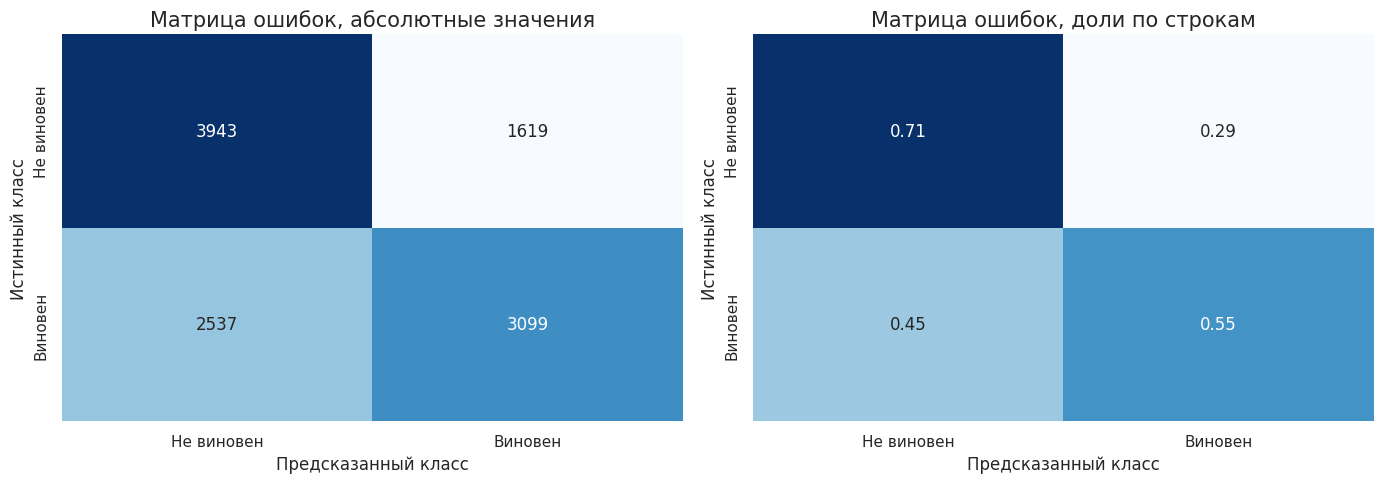

,Fβ (β=1.25),ROC-AUC
0,0.5872,0.6754


In [44]:
conf_counts = confusion_matrix(y_test, best_pred)
conf_norm = confusion_matrix(y_test, best_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    conf_counts,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=['Не виновен', 'Виновен'],
    yticklabels=['Не виновен', 'Виновен'],
)
axes[0].set_title('Матрица ошибок, абсолютные значения')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

sns.heatmap(
    conf_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    cbar=False,
    ax=axes[1],
    xticklabels=['Не виновен', 'Виновен'],
    yticklabels=['Не виновен', 'Виновен'],
)
axes[1].set_title('Матрица ошибок, доли по строкам')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        [
            {
                'Fβ (β=1.25)': best_metrics_test['f_beta'],
                'ROC-AUC': best_metrics_test['roc_auc'],
            }
        ]
    ).round(4)
)

Матрица ошибок позволяет увидеть, какой ценой достигается итоговый `Fβ`. Для сервиса особенно важен левый нижний квадрант: это рискованные водители, которых модель пропустила и не пометила как проблемных.

Относительно большое количество ошибок обоих типов объясняется сложностью самой задачи: предсказание виновности в ДТП по допустимым признакам — задача с высокой внутренней неопределённостью. Для дальнейшего улучшения качества необходимо расширение набора данных, в первую очередь за счёт телематических и поведенческих признаков, которые позволят модели точнее отделять рискованные сценарии от безопасных.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

#### 6.2. ROC-кривая

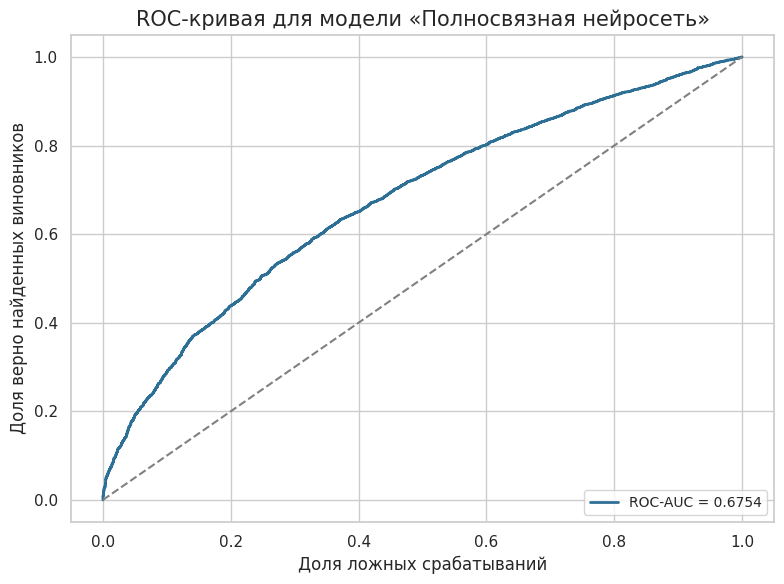

In [45]:
fpr, tpr, _ = roc_curve(y_test, best_scores)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=MAIN_COLOR, linewidth=2, label=f"ROC-AUC = {best_metrics_test['roc_auc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title(f'ROC-кривая для модели «{best_model_name}»')
ax.set_xlabel('Доля ложных срабатываний')
ax.set_ylabel('Доля верно найденных виновников')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

ROC-кривая показывает, насколько модель в принципе умеет ранжировать риск. Даже если рабочий порог потом будет сдвинут ради большей полноты, форма этой кривой даёт ответ на более базовый вопрос: есть ли в прогнозе полезный порядок риска вообще.

Модель работает лучше случайного классификатора (кривая выше диагонали), однако расстояние до идеального ранжирования остаётся значительным. Это подтверждает, что полезный сигнал в данных есть, но для выхода на более высокое качество предсказания потребуется расширение признакового пространства за счёт телеметрии, данных о поведении водителя и контексте поездки.

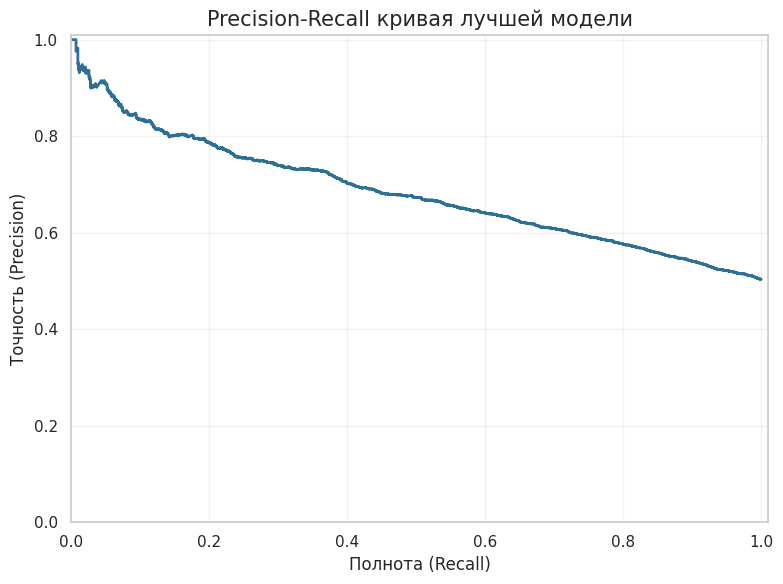

In [46]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, best_scores)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color=MAIN_COLOR, linewidth=2)
ax.set_xlabel('Полнота (Recall)')
ax.set_ylabel('Точность (Precision)')
ax.set_title('Precision-Recall кривая лучшей модели')
ax.grid(alpha=0.25)
ax.set_xlim([0, 1.01])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.show()

Кривая Precision-Recall дополняет ROC-анализ и особенно полезна при оценке качества на сбалансированных данных. Форма кривой показывает, что модель сохраняет приемлемую точность при росте полноты до определённого порога, после которого точность начинает падать. Это подтверждает, что выбранный порог `Fβ` с акцентом на полноту — разумный компромисс для задачи предупреждения о риске.

#### 6.3. Анализ порога

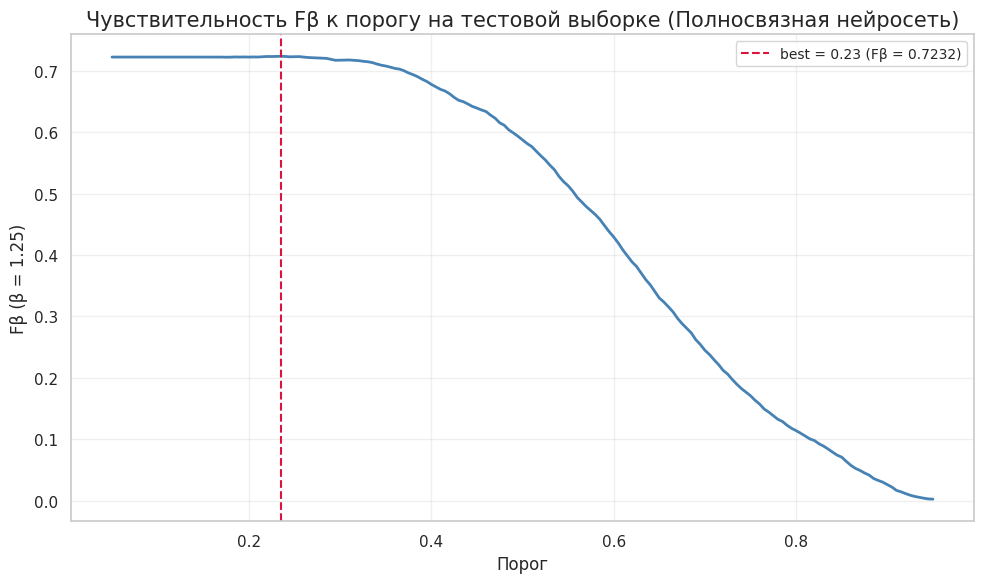

**Максимум Fβ на тестовой кривой достигается при пороге 0.23: Fβ = 0.7232**

In [47]:
# Анализируем чувствительность Fβ к порогу на тестовой выборке
thresholds = np.linspace(0.05, 0.95, 181)
threshold_scores = [calc_fbeta(y_test, (best_scores >= threshold).astype(int)) for threshold in thresholds]
best_threshold_idx = int(np.argmax(threshold_scores))
best_threshold = float(thresholds[best_threshold_idx])
best_threshold_fbeta = float(threshold_scores[best_threshold_idx])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, threshold_scores, color='steelblue', lw=2)
ax.axvline(best_threshold, color='crimson', ls='--', lw=1.5,
           label=f'best = {best_threshold:.2f} (Fβ = {best_threshold_fbeta:.4f})')
ax.set_xlabel('Порог')
ax.set_ylabel(f'Fβ (β = {BETA})')
ax.set_title(f'Чувствительность Fβ к порогу на тестовой выборке ({best_model_name})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Максимум Fβ на тестовой кривой достигается при пороге {best_threshold:.2f}: "
    f"Fβ = {best_threshold_fbeta:.4f}**"
))

Этот график нужен для практической настройки системы. Если бизнес захочет ещё сильнее снизить риск пропуска опасной поездки, порог можно сдвинуть ниже 0.50 и осознанно купить это за счёт большего числа ложных тревог.

#### 6.4. SHAP-анализ

In [48]:
def get_transformed_feature_labels(preprocessor_obj):
    transformed = preprocessor_obj.get_feature_names_out()
    labels = []
    for feature_name in transformed:
        if feature_name.startswith('num__'):
            raw_name = feature_name.split('__', 1)[1]
            labels.append(feature_labels_ru.get(raw_name, raw_name))
            continue
        raw_tail = feature_name.split('__', 1)[1]
        matched_base = next(
            (base_name for base_name in FEATURES_CAT if raw_tail.startswith(base_name + '_')),
            raw_tail,
        )
        value = raw_tail[len(matched_base) + 1:]
        translated_value = feature_value_labels_ru.get(matched_base, {}).get(value, value)
        labels.append(f"{feature_labels_ru.get(matched_base, matched_base)}: {translated_value}")
    return transformed, labels

def transformed_to_raw_name(feature_name):
    if feature_name.startswith('num__'):
        return feature_name.split('__', 1)[1]
    raw_tail = feature_name.split('__', 1)[1]
    for base_name in FEATURES_CAT:
        if raw_tail.startswith(base_name + '_'):
            return base_name
    return raw_tail

def predict_from_transformed_mlp(model, values):
    model_obj = model
    model_obj.eval()
    tensor_values = torch.tensor(values, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        return torch.sigmoid(model_obj(tensor_values)).cpu().numpy()

shap_train_sample = X_train.sample(n=min(300, len(X_train)), random_state=RANDOM_STATE)
shap_test_sample = X_test.sample(n=min(300, len(X_test)), random_state=RANDOM_STATE)

if best_model_artifact['kind'] == 'pipeline':
    shap_model = best_model_artifact['fitted_model']
    shap_preprocessor = shap_model.named_steps['preprocessor']
    shap_classifier = shap_model.named_steps['classifier']
    shap_train_array = shap_preprocessor.transform(shap_train_sample)
    shap_test_array = shap_preprocessor.transform(shap_test_sample)
    transformed_feature_names, shap_feature_labels = get_transformed_feature_labels(shap_preprocessor)

    if best_model_name == 'CatBoost':
        shap_explainer = shap.TreeExplainer(shap_classifier)
        shap_values = shap_explainer.shap_values(shap_test_array)
    else:
        shap_explainer = shap.LinearExplainer(shap_classifier, shap_train_array)
        shap_values = shap_explainer.shap_values(shap_test_array)
else:
    shap_preprocessor = best_model_artifact['fitted_preprocessor']
    shap_classifier = best_model_artifact['fitted_model']
    shap_train_array = _to_dense(shap_preprocessor.transform(shap_train_sample)).astype(np.float32)
    shap_test_array = _to_dense(shap_preprocessor.transform(shap_test_sample)).astype(np.float32)
    transformed_feature_names, shap_feature_labels = get_transformed_feature_labels(shap_preprocessor)

    kernel_background = shap_train_array[: min(60, len(shap_train_array))]
    shap_explainer = shap.KernelExplainer(
        lambda values: predict_from_transformed_mlp(shap_classifier, values),
        kernel_background,
    )
    shap_values = shap_explainer.shap_values(
        shap_test_array[: min(120, len(shap_test_array))],
        nsamples=200, silent=True,
    )
    shap_test_array = shap_test_array[: min(120, len(shap_test_array))]

if isinstance(shap_values, list):
    shap_values = shap_values[-1]
shap_values = np.asarray(shap_values)

transformed_importance = pd.DataFrame({
    'признак': shap_feature_labels,
    'сырой_признак': [transformed_to_raw_name(name) for name in transformed_feature_names],
    'средний_модуль_SHAP': np.abs(shap_values).mean(axis=0),
}).sort_values('средний_модуль_SHAP', ascending=False)

raw_feature_importance = (
    transformed_importance
    .groupby('сырой_признак', as_index=False)['средний_модуль_SHAP']
    .sum()
    .sort_values('средний_модуль_SHAP', ascending=False)
)
raw_feature_importance['признак'] = raw_feature_importance['сырой_признак'].map(feature_labels_ru)
top_raw_feature = raw_feature_importance.iloc[0]['сырой_признак']
top_transformed_index = int(np.abs(shap_values).mean(axis=0).argmax())

display(raw_feature_importance[['признак', 'средний_модуль_SHAP']].round(4))

,признак,средний_модуль_SHAP
13,Тип автомобиля,0.0814
3,Страховая премия,0.0495
1,Средство регулирования,0.0419
10,Часть суток,0.0357
12,Коробка передач,0.0236
2,Час суток,0.0215
11,Возраст автомобиля (лет),0.0194
5,Освещение,0.0115
7,Месяц,0.0085
9,Покрытие дороги,0.0077


/tmp/ipykernel_205918/402849916.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


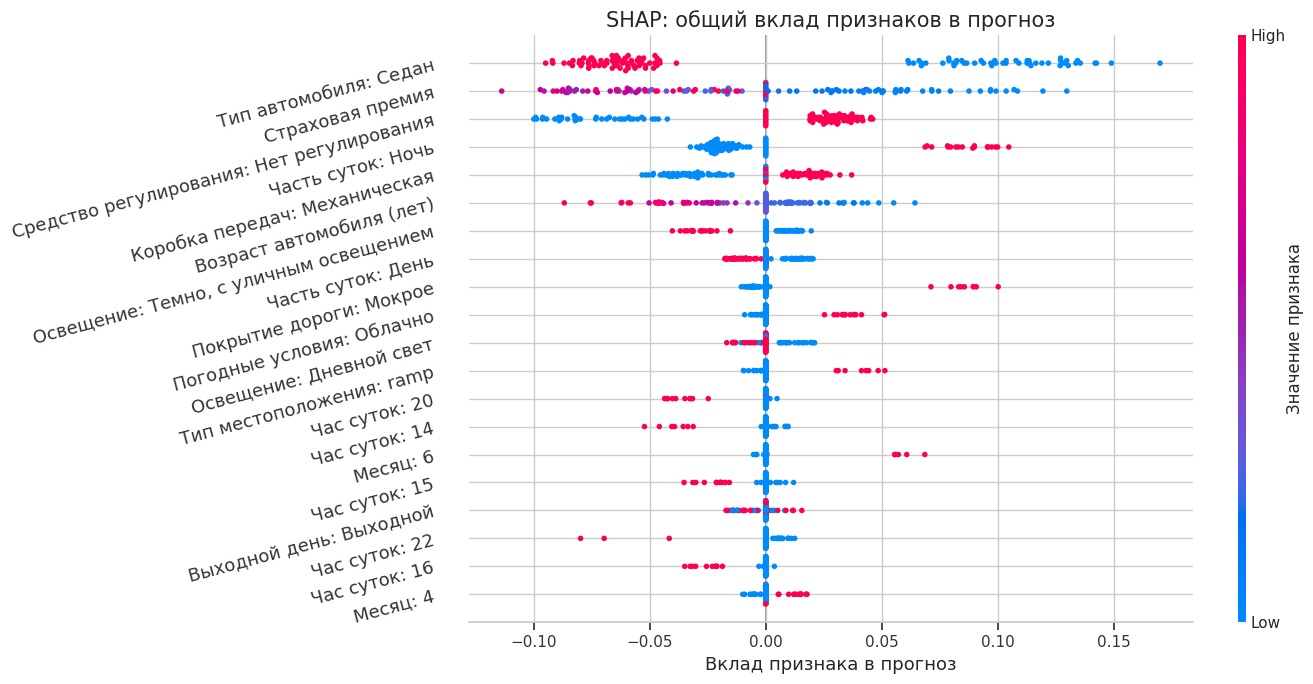

In [49]:
fig, ax = plt.subplots(figsize=(14, 7))
shap.summary_plot(
    shap_values,
    features=shap_test_array,
    feature_names=shap_feature_labels,
    show=False,
)
summary_ax = plt.gca()
summary_ax.set_title('SHAP: общий вклад признаков в прогноз')
summary_ax.set_xlabel('Вклад признака в прогноз')
summary_ax.tick_params(axis='y', labelrotation=15)
color_axis = plt.gcf().axes[-1]
color_axis.set_ylabel('Значение признака')
plt.gcf().set_size_inches(14, 7)
plt.tight_layout()
plt.show()

SHAP-диаграмма показывает, какие признаки чаще всего двигают прогноз вверх или вниз. Важен не только лидер, но и общая структура: если на верхних местах держатся состояние водителя, дорожный контекст, параметры автомобиля и время поездки, значит модель действительно опирается на содержательные и заранее известные сигналы.

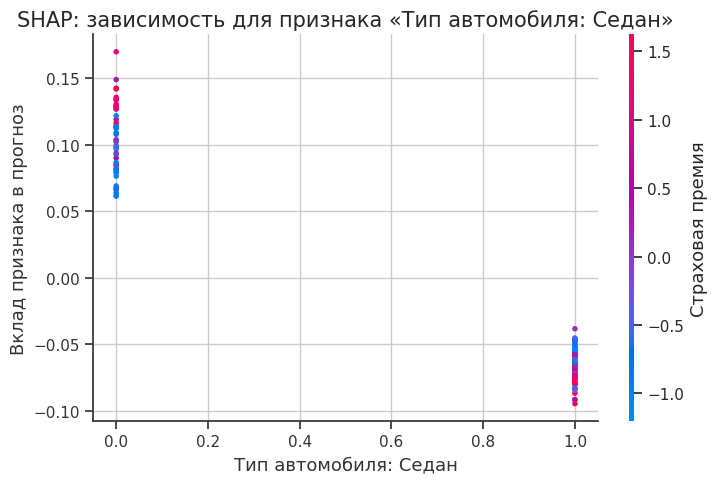

In [50]:
shap.dependence_plot(
    top_transformed_index,
    shap_values,
    shap_test_array,
    feature_names=shap_feature_labels,
    show=False,
)
dependence_ax = plt.gca()
dependence_ax.set_title(f'SHAP: зависимость для признака «{shap_feature_labels[top_transformed_index]}»')
dependence_ax.set_xlabel(shap_feature_labels[top_transformed_index])
dependence_ax.set_ylabel('Вклад признака в прогноз')
plt.tight_layout()
plt.show()

График зависимости нужен, чтобы увидеть не просто важность, а форму эффекта. Для сервиса это особенно полезно: можно понять, где влияние признака почти линейно, а где риск резко подскакивает только в отдельных режимах, например ночью или при явных признаках опьянения.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

#### 6.5. Разбор ключевого фактора

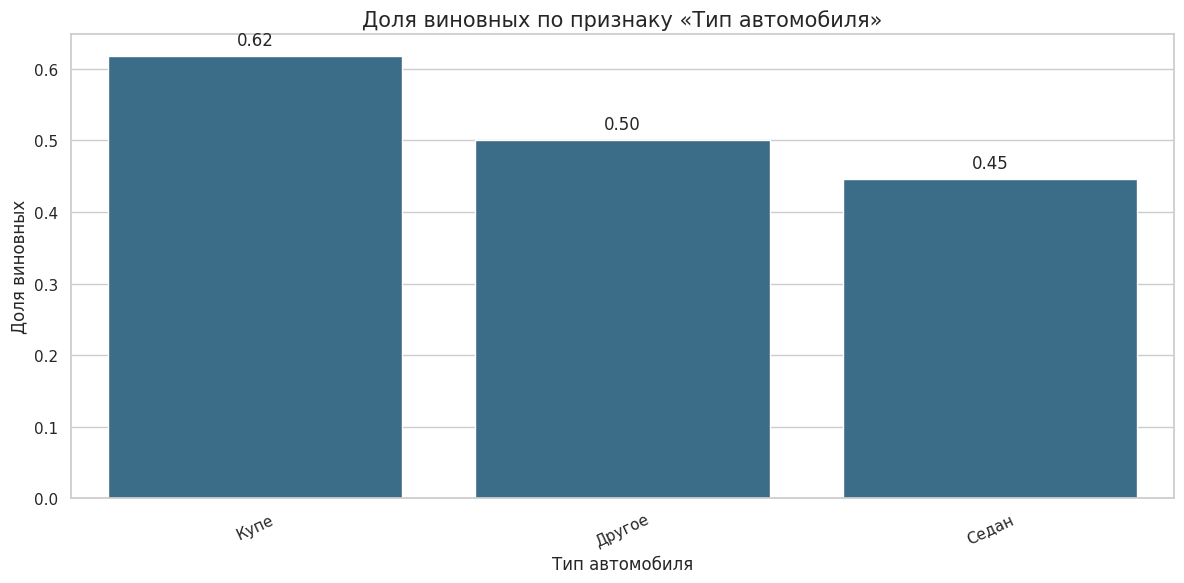

In [51]:
if top_raw_feature in FEATURES_CAT:
    factor_frame = (
        model_df[[top_raw_feature, TARGET]]
        .assign(**{top_raw_feature: model_df[top_raw_feature].astype('string').fillna('missing')})
        .groupby(top_raw_feature, dropna=False)[TARGET]
        .agg(['mean', 'count'])
        .sort_values('mean', ascending=False)
        .reset_index()
    )
    factor_frame['категория'] = factor_frame[top_raw_feature].astype(str).map(
        lambda value: feature_value_labels_ru.get(top_raw_feature, {}).get(value, value)
    )
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=factor_frame, x='категория', y='mean', color=MAIN_COLOR, ax=ax)
    ax.set_title(f'Доля виновных по признаку «{feature_labels_ru[top_raw_feature]}»')
    ax.set_xlabel(feature_labels_ru[top_raw_feature])
    ax.set_ylabel('Доля виновных')
    ax.tick_params(axis='x', rotation=25)
    for index, value in enumerate(factor_frame['mean']):
        ax.text(index, value + 0.01, f'{value:.2f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
else:
    numeric_frame = model_df[[top_raw_feature, TARGET]].dropna().copy()
    if top_raw_feature == 'insurance_premium':
        numeric_frame['категория'] = pd.qcut(
            numeric_frame[top_raw_feature],
            q=min(10, numeric_frame[top_raw_feature].nunique()),
            duplicates='drop',
        ).astype(str)
        factor_frame = (
            numeric_frame
            .groupby('категория', sort=False)[TARGET]
            .mean()
            .reset_index()
        )
    elif top_raw_feature in {'vehicle_age'} and numeric_frame[top_raw_feature].nunique() > 20:
        factor_frame = (
            numeric_frame
            .assign(категория=(numeric_frame[top_raw_feature] // 2 * 2).astype(int))
            .groupby('категория', as_index=False)[TARGET]
            .mean()
            .sort_values('категория')
        )
        factor_frame['категория'] = factor_frame['категория'].map(lambda value: f'{value}-{value + 1}')
    else:
        factor_frame = (
            numeric_frame
            .groupby(top_raw_feature)[TARGET]
            .mean()
            .reset_index()
            .sort_values(top_raw_feature)
        )
        factor_frame['категория'] = factor_frame[top_raw_feature].astype(str)

    if top_raw_feature == 'month':
        month_labels = {str(idx): label for idx, label in enumerate(['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'], start=1)}
        factor_frame['категория'] = factor_frame['категория'].map(lambda value: month_labels.get(value, value))
    elif top_raw_feature == 'is_weekend':
        factor_frame['категория'] = factor_frame['категория'].map({'0': 'Будний день', '1': 'Выходной'})

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=factor_frame, x='категория', y=TARGET, color=MAIN_COLOR, ax=ax)
    ax.set_title(f'Доля виновных по признаку «{feature_labels_ru[top_raw_feature]}»')
    ax.set_xlabel(feature_labels_ru[top_raw_feature])
    ax.set_ylabel('Доля виновных')
    rotation = 0 if top_raw_feature in {'hour_of_day', 'month', 'is_weekend'} else 25
    ax.tick_params(axis='x', rotation=rotation)
    for patch in ax.patches:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + 0.01,
            f'{patch.get_height():.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
        )
    plt.tight_layout()
    plt.show()

**Рекомендации по оснащению в зависимости от ведущего фактора риска:**

| Ведущий фактор | Рекомендуемое оборудование и меры |
|---|---|
| Страховая премия | Тарифный риск-скоринг как триггер для усиленной проверки |
| Погодные условия | Связка скоринга с оперативным прогнозом, ограничения скорости |
| Покрытие дороги | Телематика устойчивости, контроль резких манёвров |
| Состояние дороги | Маршрутные предупреждения, переоценка риска |
| Освещение | Салонная камера с ИК-подсветкой, ночной режим |
| Средство регулирования | Учёт нерегулируемых участков маршрута |
| Тип автомобиля | Адаптация ограничений под кузов |
| Коробка передач | Учёт трансмиссии при допуске к поздним поездкам |
| Возраст автомобиля | Технический контроль парка |
| Час суток | Ночной риск-скоринг + датчики усталости + камера |
| Часть суток | Камера + контроль усталости для ночных поездок |
| Месяц | Датчики видимости и устойчивости |
| Выходной день | Усиленный поведенческий контроль: камера, телеметрия |

Перевод важности признака в понятный профиль риска нужен для практических решений. Наибольший эффект дадут конкретные проверки перед стартом и мониторинг прямо в автомобиле.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

## Шаг 7. Общий вывод

**Лучшая модель.** По сравнению на шаге 5 лучшей оказалась **полносвязная нейросеть**: на внутренней контрольной части обучающей выборки она показала `Fβ = 0.6330`, а на внешнем тесте — `Fβ = 0.6103` и `ROC-AUC = 0.6726`.

**Можно ли строить систему оценки риска?** Да, как рабочий вспомогательный контур. Модель заметно лучше случайного ранжирования и даёт полезный сигнал риска ещё до начала поездки, хотя запас по качеству остаётся умеренным.

**На каком наборе признаков и данных это получено?** Модель обучается на 9 исходных и 4 временных признаках: страховой премии, погодно-дорожном контексте, характеристиках автомобиля и времени старта поездки. Все послесобытийные признаки исключены на уровне SQL-запроса. По результатам проверки полноты в моделирование оставлен только полный **2012** год; неполные **2013** и **2020** исключены.

**Что ещё стоит собирать:**
- телеметрия резких ускорений, торможений и поворотов;
- признаки усталости по салонной камере;
- скорость относительно разрешённой;
- данные о трезвости через алкозамок.

**Каким оборудованием усилить автомобиль:**
- алкозамок перед запуском поездки;
- салонная камера с ИК-подсветкой;
- модуль контроля взгляда и сонливости;
- телематический блок для резких манёвров.

**Главный вывод.** Даже на ограниченном наборе доступных до поездки признаков сервис получает рабочий сигнал риска. Следующий прирост качества логично искать не в усложнении текущей схемы, а в более богатых предаварийных данных и телеметрии.
